# Mamba vs SimpleStories Transformer — Comparative Evaluation

This notebook loads:
* A trained Mamba SSM checkpoint (from `tpu_train.py`)
* The matched SimpleStories pretrained transformer (e.g. `SimpleStories/SimpleStories-5M`)

…and runs six experiments to compare them on the SimpleStories test split:

| # | Experiment | What it measures |
|---|---|---|
| 1 | Test BPB / perplexity / top-k accuracy | Held-out language-model quality |
| 2 | Inference benchmark | Decode tok/s, prefill tok/s, state memory |
| 3 | Loss vs sequence length | Long-context extrapolation (Mamba's design pitch) |
| 4 | Per-position loss | Does the model use its context? |
| 5 | Selective copying / induction | In-context retrieval (Mamba's selectivity claim) |
| 6 | Diversity (self-BLEU / distinct-n / repetition) | Mode collapse / sample variety |

Designed to run on Google Colab (T4 / A100 GPU or CPU). All models load in fp32 by default for fair comparison.


## 1. Setup


In [1]:
# Install dependencies. Skip if already on the host.
# - triton: required for the CUDA fused-scan kernel
# - mauve-text: distributional quality metric for Experiment 7
# - sentence-transformers: sentence-level embedding drift metric
# - accelerate + bitsandbytes: 4-bit quantization for the open-source
#   judge model in Experiment 7 (graceful fallback if unavailable)
%pip install -q torch triton transformers datasets einops tqdm matplotlib pandas nltk wandb
%pip install -q mauve-text sentence-transformers
%pip install -q accelerate bitsandbytes
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.3 MB/s eta 0:00:00


True

### Get the project source

The notebook needs `mamba/mamba_llm_tpu.py` and `mamba/xla_fused_scan.py` from the
project repo to reconstruct the Mamba model. Adjust `REPO_URL` to your fork.

If you've already uploaded the project files to Colab (or are running locally), set
`REPO_DIR` to the existing path and skip the clone.


In [2]:
import os, sys

REPO_URL = "https://github.com/JackMclaughlin424/csci739-project-mamba.git"
REPO_DIR = "csci739-project-mamba"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL}

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# If running locally from the project root, the repo is just the cwd:
if not os.path.exists(os.path.join(REPO_DIR, "mamba")):
    if os.path.exists("mamba"):
        REPO_DIR = "."
    else:
        raise FileNotFoundError("Couldn't find the mamba/ directory")

print(f"REPO_DIR = {REPO_DIR}")


Cloning into 'csci739-project-mamba'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 592 (delta 126), reused 150 (delta 67), pack-reused 344 (from 1)
Receiving objects: 100% (592/592), 4.85 MiB | 18.54 MiB/s, done.
Resolving deltas: 100% (257/257), done.
REPO_DIR = csci739-project-mamba


In [3]:
import math, time, json, statistics
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from nltk import ngrams
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# CUDA setup flags (no-ops on CPU). TF32 doubles fp32 matmul throughput on
# Ampere+ with imperceptible accuracy impact; cudnn.benchmark lets cuDNN
# pick the fastest depthwise-conv1d algorithm on first call.
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

# Pick the Triton-backed CUDA path when CUDA is available, else fall back
# to the TPU/pure-PyTorch path. Both modules expose identical state_dict
# keys so a TPU-trained checkpoint loads `strict=True` either way.
if torch.cuda.is_available():
    from mamba.mamba_llm_cuda import MambaLMHeadModel, MambaLMConfig, HAS_TRITON
    print(f"Using mamba_llm_cuda (Triton-backed). Triton available: {HAS_TRITON}")
    if not HAS_TRITON:
        print("  WARNING: Triton kernel will fall back to a pure-PyTorch sequential")
        print("  scan that is unusably slow at L >= 256. Install triton, or fall back")
        print("  to mamba.mamba_llm_tpu by editing this cell.")
else:
    from mamba.mamba_llm_tpu import MambaLMHeadModel, MambaLMConfig
    HAS_TRITON = False
    print("CUDA unavailable; using mamba_llm_tpu (pure-PyTorch parallel scan).")

print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")


Using mamba_llm_cuda (Triton-backed). Triton available: True
torch 2.10.0+cu128 | cuda available: True


## 2. Configuration

Edit these to point at your specific checkpoint and matched baseline.


In [4]:
# ─── Mamba checkpoint source ────────────────────────────────────────────
# Pick ONE: a local path, a wandb artifact, or upload to Colab and set the path.
MAMBA_CHECKPOINT_PATH = None  # local file
MAMBA_WANDB_ARTIFACT  = "doryvf-rochester-institute-of-technology/mamba-simplestories/mamba-5m-4p0yj3pe:best"    # e.g. "entity/mamba-simplestories/mamba-5m-{run_id}:best"

# ─── SimpleStories baseline (size should match the Mamba) ───────────────
HF_TRANSFORMER_MODEL = "SimpleStories/SimpleStories-5M"
HF_TOKENIZER         = "SimpleStories/SimpleStories-5M"

# ─── Test data ──────────────────────────────────────────────────────────
DATASET_NAME    = "lennart-finke/SimpleStories"
DATASET_SPLIT   = "test"
TEXT_COLUMN     = "story"
LOWERCASE       = True       # match training preprocessing
SEQ_LEN         = 512        # trained context length
MAX_TEST_STORIES = 0      # cap for Colab speed; set 0 for full split

# ─── Inference benchmark ────────────────────────────────────────────────
INFERENCE_DECODE_TOKENS  = 100
INFERENCE_PREFILL_LENS   = [128, 512, 1024, 2048]

# ─── Loss-vs-length test ────────────────────────────────────────────────
LONG_CONTEXT_LENS = [128, 256, 512, 1024, 2048]

# ─── Selective-copy / induction test ────────────────────────────────────
INDUCTION_DISTANCES = [4, 8, 16, 32, 64, 128, 256]
INDUCTION_TRIALS    = 500     # per distance per model
                              # 50 was too few — at vocab=4096 the random
                              # baseline gives 0.012 expected hits per 50,
                              # making "0/50" indistinguishable from a weak
                              # but real induction signal. The headline
                              # metric is 2AFC top-1 (50% baseline), which
                              # 500 trials makes statistically meaningful
                              # (95% CI half-width ≈ 4.4pp).

# ─── Diversity test ─────────────────────────────────────────────────────
DIVERSITY_PROMPTS = [
    "once upon a time,",
    "there was a little girl named",
    "the dog ran",
    "in a small village,",
]
DIVERSITY_GENS_PER_PROMPT = 20
DIVERSITY_MAX_NEW_TOKENS  = 80
DIVERSITY_TEMPERATURE     = 0.8
DIVERSITY_TOP_K           = 40

# ─── Hardware / precision ───────────────────────────────────────────────
USE_GPU = torch.cuda.is_available()
EVAL_BATCH_SIZE = 8 if USE_GPU else 2

# Quality metrics (Experiment 1 test BPB, Experiment 3 long-context loss)
# stay in fp32 to keep the cross-architecture comparison apples-to-apples.
DTYPE = torch.float32

# Inference benchmark (Experiment 2: prefill TPS / decode TPS) is reported
# at BOTH fp32 (matches the quality-metric configuration) AND the
# realistic deployment dtype — fp16 on T4/V100 (no bf16 hardware), bf16
# on Ampere+. The deployment number is what anyone serving these models
# would actually see; reporting only fp32 understates Mamba's inference
# advantage. SSM state stays fp32 either way (numerical stability — see
# `MambaBlock.allocate_inference_cache`).
if USE_GPU:
    _major = torch.cuda.get_device_capability()[0]
    INFERENCE_DTYPE_DEPLOY = torch.bfloat16 if _major >= 8 else torch.float16
else:
    INFERENCE_DTYPE_DEPLOY = torch.float32        # CPU has no half-precision matmul speedup

device = torch.device("cuda" if USE_GPU else "cpu")
print(f"Using device: {device}")
print(f"Quality metrics dtype:    {DTYPE}")
print(f"Inference benchmark also runs at: {INFERENCE_DTYPE_DEPLOY}")
torch.manual_seed(42)


Using device: cuda
Quality metrics dtype:    torch.float32
Inference benchmark also runs at: torch.bfloat16


## 3. Load both models


In [5]:
def load_mamba(path=None, wandb_artifact=None):
    """Load a Mamba checkpoint produced by tpu_train.py."""
    if wandb_artifact:
        import wandb
        if wandb.run is None:
            wandb.login()
        api = wandb.Api()
        artifact = api.artifact(wandb_artifact, type="model")
        d = artifact.download()
        files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith(".pt")]
        if not files:
            raise RuntimeError(f"No .pt in artifact {wandb_artifact}")
        path = files[0]
    if not path or not os.path.exists(path):
        raise FileNotFoundError(f"Mamba checkpoint not found: {path}")
    payload = torch.load(path, map_location='cpu', weights_only=False)
    cfg = MambaLMConfig(**payload['config'])
    model = MambaLMHeadModel(cfg)
    model.load_state_dict(payload['state_dict'], strict=True)
    model.to(device).to(DTYPE).eval()
    return model, cfg, payload

mamba, mamba_cfg, mamba_payload = load_mamba(MAMBA_CHECKPOINT_PATH, MAMBA_WANDB_ARTIFACT)

n_params_mamba = mamba.num_parameters(unique=True)
n_params_mamba_non_embed = n_params_mamba - mamba.embedding.weight.numel()
print(f"Mamba loaded:")
print(f"  n_layer={mamba_cfg.n_layer}  d_input={mamba_cfg.d_input}  d_model={mamba_cfg.d_model}")
print(f"  d_state={mamba_cfg.d_state}  dt_rank={mamba_cfg.dt_rank}  seq_len={mamba_cfg.seq_len}")
print(f"  n_params unique: {n_params_mamba:,}  (non-embedding: {n_params_mamba_non_embed:,})")
print(f"  checkpoint metadata: step={mamba_payload.get('global_step')}, "
      f"epoch={mamba_payload.get('epoch')}, val_loss={mamba_payload.get('val_loss')}")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: doryvf (doryvf-rochester-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Downloading large artifact 'mamba-5m-4p0yj3pe:best', 62.94MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.0 (31.7MB/s)


Mamba loaded:
  n_layer=9  d_input=256  d_model=512
  d_state=16  dt_rank=32  seq_len=512
  n_params unique: 5,138,432  (non-embedding: 4,089,856)
  checkpoint metadata: step=7629, epoch=None, val_loss=1.9199180603027344


In [6]:
# Load the matched SimpleStories transformer + tokenizer.
print(f"Loading {HF_TRANSFORMER_MODEL} ...")
tokenizer = AutoTokenizer.from_pretrained(HF_TOKENIZER)
try:
    transformer = AutoModelForCausalLM.from_pretrained(
        HF_TRANSFORMER_MODEL, dtype=DTYPE,
    ).to(device).eval()
except Exception as e:
    # Some SimpleStories uploads may need trust_remote_code=True.
    print(f"Standard loader failed ({e!r}); retrying with trust_remote_code=True")
    transformer = AutoModelForCausalLM.from_pretrained(
        HF_TRANSFORMER_MODEL, dtype=DTYPE, trust_remote_code=True,
    ).to(device).eval()

n_params_xfmr = sum(p.numel() for p in transformer.parameters())
print(f"Transformer loaded: {n_params_xfmr:,} params")
print(f"  config: {transformer.config}")


Loading SimpleStories/SimpleStories-5M ...


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/56 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Transformer loaded: 5,374,208 params
  config: LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "dtype": "float32",
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 256,
  "initializer_range": 0.02,
  "intermediate_size": 682,
  "max_position_embeddings": 512,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 4,
  "num_hidden_layers": 6,
  "num_key_value_heads": 2,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-06,
  "rope_parameters": {
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 4096
}



## 4. Unified interface

Both models need a `forward(input_ids) → logits` and a `step(input_ids, cache) → (logits, new_cache)` so the same evaluation/generation code works for either.


In [7]:
class MambaInterface:
    name = "Mamba"
    def __init__(self, model, cfg):
        self.model, self.cfg = model, cfg

    @torch.inference_mode()
    def forward(self, input_ids):                  # (B, L) int → (B, L, V)
        return self.model(input_ids)

    def allocate_cache(self, batch_size):
        # Conv state must match the model's parameter dtype: it flows
        # through (conv_state * weight).sum(-1) which promotes to the
        # wider dtype, then F.linear rejects the mismatch with the bf16
        # projection weights downstream. SSM state stays fp32 regardless
        # (hardcoded inside MambaBlock.allocate_inference_cache for
        # numerical stability — the recurrence accumulates and bf16
        # underflows on long L).
        model_dtype = next(self.model.parameters()).dtype
        return self.model.allocate_inference_cache(
            batch_size, dtype=model_dtype, device=device,
        )

    @torch.inference_mode()
    def step(self, input_ids, cache):              # (B,) int → (B, V), cache
        return self.model.step(input_ids, cache)

    @property
    def n_params(self):
        return self.model.num_parameters(unique=True)

    def state_size_bytes(self, batch_size, seq_len):
        # Mamba state = 2 × n_layer × B × d_model × (kernel + d_state) × 4 bytes (fp32).
        # CONSTANT in seq_len — that's the whole story.
        c = self.cfg
        return 2 * c.n_layer * batch_size * c.d_model * (c.kernel_size + c.d_state) * 4


class TransformerInterface:
    name = "Transformer"
    def __init__(self, model, tokenizer):
        self.model, self.tokenizer = model, tokenizer
        self.cfg = model.config

    @torch.inference_mode()
    def forward(self, input_ids):
        return self.model(input_ids=input_ids).logits

    def allocate_cache(self, batch_size):
        return None        # HF starts decoding with past_key_values=None

    @torch.inference_mode()
    def step(self, input_ids, cache):
        outputs = self.model(
            input_ids=input_ids.unsqueeze(-1),     # (B, 1)
            past_key_values=cache,
            use_cache=True,
        )
        return outputs.logits[:, -1, :], outputs.past_key_values

    @property
    def n_params(self):
        return sum(p.numel() for p in self.model.parameters())

    def state_size_bytes(self, batch_size, seq_len):
        # KV cache after `seq_len` tokens:
        #   2 (k,v) × n_layer × B × n_kv × d_head × seq_len × 4 bytes (fp32)
        c = self.cfg
        n_heads = getattr(c, "num_attention_heads", None) or getattr(c, "n_head", 1)
        n_kv    = getattr(c, "num_key_value_heads", n_heads)
        d_model = getattr(c, "hidden_size", None) or getattr(c, "n_embd", n_heads * 64)
        d_head  = d_model // n_heads
        n_layer = (getattr(c, "num_hidden_layers", None) or
                   getattr(c, "n_layer", 1))
        return 2 * n_layer * batch_size * n_kv * d_head * seq_len * 4


mamba_iface = MambaInterface(mamba, mamba_cfg)
xfmr_iface  = TransformerInterface(transformer, tokenizer)
print(f"Mamba: {mamba_iface.n_params:,} params")
print(f"Transformer: {xfmr_iface.n_params:,} params")


Mamba: 5,138,432 params
Transformer: 5,374,208 params


### Sanity check — both forward + step on a tiny input


In [8]:
test_ids = torch.tensor([[1, 2, 3, 4, 5]], device=device)
with torch.inference_mode():
    print(f"Mamba forward shape:       {mamba_iface.forward(test_ids).shape}")
    print(f"Transformer forward shape: {xfmr_iface.forward(test_ids).shape}")

# Step path
for iface in (mamba_iface, xfmr_iface):
    cache = iface.allocate_cache(batch_size=1)
    next_tok = torch.tensor([1], device=device)
    logits, cache = iface.step(next_tok, cache)
    print(f"{iface.name} step output shape: {logits.shape}")
print("Sanity OK")


Mamba forward shape:       torch.Size([1, 5, 4096])
Transformer forward shape: torch.Size([1, 5, 4096])
Mamba step output shape: torch.Size([1, 4096])
Transformer step output shape: torch.Size([1, 4096])
Sanity OK


## 5. Tokenize the SimpleStories test split

Same recipe as `tpu_train.py`: lowercase → fast BPE → EOS-separated stream → packed `(N, seq_len+1)` chunks. This makes test-loss numbers directly comparable to training-time val-loss numbers.


In [9]:
print(f"Loading {DATASET_NAME} (split={DATASET_SPLIT})...")
ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
ds = ds.select_columns([TEXT_COLUMN])
if MAX_TEST_STORIES:
    ds = ds.select(range(min(MAX_TEST_STORIES, len(ds))))
print(f"  {len(ds):,} stories")

eos_id = tokenizer.eos_token_id
if eos_id is None:
    eos_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    print(f"  no EOS → using id={eos_id} as separator")

def tokenize_fn(examples):
    texts = examples[TEXT_COLUMN]
    if LOWERCASE:
        texts = [t.lower() for t in texts]
    nbytes = [len(t.encode('utf-8')) for t in texts]
    encoded = tokenizer(texts, add_special_tokens=False)['input_ids']
    return {'ids': [seq + [eos_id] for seq in encoded], 'nbytes': nbytes}

ds_tok = ds.map(tokenize_fn, batched=True, batch_size=500,
                remove_columns=ds.column_names, desc='tokenize')

stream, total_bytes = [], 0
for ex in tqdm(ds_tok, desc='concat'):
    stream.extend(ex['ids']); total_bytes += ex['nbytes']

bytes_per_token = total_bytes / max(len(stream), 1)
print(f"\nTotal tokens: {len(stream):,}  bytes/token: {bytes_per_token:.3f}")

chunk_size = SEQ_LEN + 1
n_chunks = len(stream) // chunk_size
test_data = torch.tensor(stream[:n_chunks * chunk_size], dtype=torch.long).view(n_chunks, chunk_size)
print(f"Packed test data: {test_data.shape}")


Loading lennart-finke/SimpleStories (split=test)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/21371 [00:00<?, ? examples/s]

  21,371 stories


tokenize:   0%|          | 0/21371 [00:00<?, ? examples/s]

concat:   0%|          | 0/21371 [00:00<?, ?it/s]


Total tokens: 6,148,046  bytes/token: 4.299
Packed test data: torch.Size([11984, 513])


## Experiment 1 — Held-out test loss / perplexity / accuracy

Standard LM evaluation. Both models see the same packed `(x, y)` pairs and the loss is computed via mean cross-entropy. **BPB is the apples-to-apples cross-architecture metric** since both use the same tokenizer.


In [10]:
LOG2_E = 1.0 / math.log(2.0)
def bits_per_byte(loss_nats, bpt):
    return loss_nats * LOG2_E / bpt

@torch.inference_mode()
def evaluate_test(iface, data, batch_size=8, bpt=None):
    # Defensive: eval mode disables dropout/etc even if a stray .train()
    # was called by an earlier notebook cell.
    iface.model.eval()
    n = data.shape[0]
    # Accumulate metrics on-device — one .cpu() at the very end instead
    # of per-batch .item() syncs. We also record per-chunk loss so the
    # writeup can bootstrap a 95% CI on test BPB instead of reporting a
    # bare point estimate.
    sum_loss = torch.zeros(1, device=device, dtype=torch.float64)
    sum_top1 = torch.zeros(1, device=device, dtype=torch.float64)
    sum_top5 = torch.zeros(1, device=device, dtype=torch.float64)
    per_chunk_losses = []      # one float per (B, L-1) chunk; for CIs
    n_batches = 0
    for i in tqdm(range(0, n, batch_size), desc=f'eval {iface.name}'):
        chunk = data[i:i+batch_size].to(device)
        if chunk.size(0) == 0:
            break
        x, y = chunk[:, :-1], chunk[:, 1:]
        logits = iface.forward(x)
        flat_l = logits.view(-1, logits.size(-1))
        flat_t = y.contiguous().view(-1)
        sum_loss += F.cross_entropy(flat_l, flat_t, reduction='mean').double()
        sum_top1 += (flat_l.argmax(-1) == flat_t).double().mean()
        topk = flat_l.topk(5, dim=-1).indices
        sum_top5 += (topk == flat_t.unsqueeze(-1)).any(-1).double().mean()
        # Per-chunk loss: averaged over the (L-1) positions of each chunk.
        # cross_entropy reduction='none' returns per-position loss; mean
        # per chunk gives one number per packed story-window.
        chunk_losses = F.cross_entropy(flat_l, flat_t, reduction='none')\
                          .view(chunk.size(0), -1).mean(dim=-1).float().cpu().tolist()
        per_chunk_losses.extend(chunk_losses)
        n_batches += 1
    # One synchronisation point.
    avg = (torch.stack([sum_loss, sum_top1, sum_top5]) / max(n_batches, 1)).cpu().tolist()
    avg_loss, avg_top1, avg_top5 = avg[0][0], avg[1][0], avg[2][0]
    bpt = bpt if bpt is not None else bytes_per_token
    return {
        'loss':              avg_loss,
        'perplexity':        math.exp(min(avg_loss, 20)),
        'bpb':               bits_per_byte(avg_loss, bpt),
        'top1':              avg_top1,
        'top5':              avg_top5,
        'n_chunks':          int(n),
        'n_tokens_evaluated': int(n) * (data.shape[1] - 1),  # (L-1) targets per chunk
        'per_chunk_losses':  per_chunk_losses,                # for bootstrap CIs
    }

results_test = {}
for iface in (mamba_iface, xfmr_iface):
    print(f"\n══ {iface.name} ══")
    r = evaluate_test(iface, test_data, batch_size=EVAL_BATCH_SIZE)
    results_test[iface.name] = r
    # Print the headline stats only (per_chunk_losses is large; saved to JSON).
    for k, v in r.items():
        if k == 'per_chunk_losses':
            continue
        print(f"  {k:22s} = {v if isinstance(v, int) else f'{v:.4f}'}")
    # Bootstrap 95% CI on the mean loss using the per-chunk samples.
    losses = np.asarray(r['per_chunk_losses'])
    boot   = np.array([losses[np.random.randint(0, len(losses), len(losses))].mean()
                       for _ in range(2000)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"  loss 95% CI (bootstrap, 2000 resamples): [{lo:.4f}, {hi:.4f}]")



══ Mamba ══


eval Mamba:   0%|          | 0/1498 [00:00<?, ?it/s]

  loss                   = 1.9178
  perplexity             = 6.8061
  bpb                    = 0.6436
  top1                   = 0.5225
  top5                   = 0.8022
  n_chunks               = 11984
  n_tokens_evaluated     = 6135808
  loss 95% CI (bootstrap, 2000 resamples): [1.9142, 1.9212]

══ Transformer ══


eval Transformer:   0%|          | 0/1498 [00:00<?, ?it/s]

  loss                   = 1.8850
  perplexity             = 6.5864
  bpb                    = 0.6326
  top1                   = 0.5290
  top5                   = 0.8086
  n_chunks               = 11984
  n_tokens_evaluated     = 6135808
  loss 95% CI (bootstrap, 2000 resamples): [1.8818, 1.8884]


In [11]:
# Side-by-side table — drop per_chunk_losses (huge list; JSON-only).
_HIDE_COLS = {'per_chunk_losses'}
df_test = pd.DataFrame({n: {k: v for k, v in r.items() if k not in _HIDE_COLS}
                        for n, r in results_test.items()}).T
df_test.index.name = 'model'
df_test


,loss,perplexity,bpb,top1,top5,n_chunks,n_tokens_evaluated
model,,,,,,,
Mamba,1.917815,6.806070,0.643588,0.522532,0.802192,11984.0,6135808.0
Transformer,1.885000,6.586355,0.632576,0.529018,0.808615,11984.0,6135808.0


## Experiment 1b — Out-of-distribution perplexity (WikiText-2)

Sanity-check that the matched test-BPB result is not an artifact of the SimpleStories distribution. Same tokenizer, same eval loop — but score a small slice of WikiText-2 (general-domain English) instead of children's stories.

Both models were trained on SimpleStories only, so absolute PPL will be high. The interesting number is the **gap between Mamba and the transformer** — if it stays the same magnitude as on the in-distribution test, generalization is comparable.


In [12]:
OOD_DATASET    = "wikitext"
OOD_CONFIG     = "wikitext-2-raw-v1"
OOD_SPLIT      = "test"
OOD_MAX_DOCS   = 1000   # cap for Colab speed (full split is ~4.4K rows)

print(f"Loading OOD: {OOD_DATASET}/{OOD_CONFIG} split={OOD_SPLIT}")
ood_ds = load_dataset(OOD_DATASET, OOD_CONFIG, split=OOD_SPLIT)
ood_ds = ood_ds.select(range(min(OOD_MAX_DOCS, len(ood_ds))))

ood_stream, ood_total_bytes = [], 0
for ex in tqdm(ood_ds, desc='ood-tokenize'):
    txt = ex['text']
    if not txt.strip():
        continue
    if LOWERCASE:
        txt = txt.lower()
    ood_total_bytes += len(txt.encode('utf-8'))
    ood_stream.extend(tokenizer.encode(txt, add_special_tokens=False) + [eos_id])

ood_bpt = ood_total_bytes / max(len(ood_stream), 1)
ood_n_chunks = len(ood_stream) // (SEQ_LEN + 1)
ood_data = torch.tensor(ood_stream[:ood_n_chunks * (SEQ_LEN + 1)],
                        dtype=torch.long).view(ood_n_chunks, SEQ_LEN + 1)
print(f"\nOOD: {len(ood_stream):,} tokens  bytes/token: {ood_bpt:.3f}  chunks: {ood_n_chunks:,}")

results_ood = {}
for iface in (mamba_iface, xfmr_iface):
    print(f"\n══ OOD / {iface.name} ══")
    r = evaluate_test(iface, ood_data, batch_size=EVAL_BATCH_SIZE, bpt=ood_bpt)
    results_ood[iface.name] = r
    for k, v in r.items():
        if k == 'per_chunk_losses':
            continue
        print(f"  {k:22s} = {v if isinstance(v, int) else f'{v:.4f}'}")

# Print the in-dist vs OOD gap so the writeup can quote both numbers.
print(f"\n── OOD gap relative to in-distribution test ──")
for name in results_ood:
    in_loss  = results_test[name]['loss']
    ood_loss = results_ood[name]['loss']
    print(f"  {name:12s}  in-dist loss={in_loss:.4f}  OOD loss={ood_loss:.4f}  Δ={ood_loss-in_loss:+.4f}")


Loading OOD: wikitext/wikitext-2-raw-v1 split=test


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...


OOD: 105,464 tokens  bytes/token: 2.989  chunks: 205

══ OOD / Mamba ══


eval Mamba:   0%|          | 0/26 [00:00<?, ?it/s]

  loss                   = 6.6034
  perplexity             = 737.6315
  bpb                    = 3.1872
  top1                   = 0.1690
  top5                   = 0.3297
  n_chunks               = 205
  n_tokens_evaluated     = 104960

══ OOD / Transformer ══


eval Transformer:   0%|          | 0/26 [00:00<?, ?it/s]

  loss                   = 6.6089
  perplexity             = 741.6342
  bpb                    = 3.1898
  top1                   = 0.1650
  top5                   = 0.3225
  n_chunks               = 205
  n_tokens_evaluated     = 104960

── OOD gap relative to in-distribution test ──
  Mamba         in-dist loss=1.9178  OOD loss=6.6034  Δ=+4.6856
  Transformer   in-dist loss=1.8850  OOD loss=6.6089  Δ=+4.7239


## Experiment 2 — Inference benchmark

Single-stream (batch=1) measurements — what one serving user sees. Mamba's claims:
* O(1) per-token decode (no growing KV cache)
* Inference state size **constant in sequence length**

We report decode tok/s, prefill tok/s at multiple lengths, and analytical state size up to the longest sequence we'd realistically serve.


In [13]:
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

# Try to opt into torch.compile for the decode step. step() is a
# fixed-shape recurrent kernel called 100+ times — ideal for Inductor's
# kernel fusion. We DO NOT compile forward() (the prefill path) because
# it goes through `_XlaFusedSSM.apply` (a custom autograd.Function) which
# torch.compile may graph-break on — measure separately if you want it.
#
# `mode="default"` is the safe choice: kernel fusion + autotuning, but
# NO CUDA Graphs. The more aggressive `"reduce-overhead"` mode wraps
# the compiled function in CUDA Graphs which requires fully-static
# input/output identity — incompatible with our `(conv_state, ssm_state)`
# tuple cache (the tuple is rebuilt per call) and with the lazily-
# populated `_A_neg_exp_cache` Python attribute. If you want to try
# CUDA Graphs explicitly, use `USE_CUDA_GRAPHS = True` further below.
USE_TORCH_COMPILE = True            # set False to skip compile entirely

# Suppress Dynamo errors so any per-step recompile that hits a graph
# break degrades gracefully to eager instead of crashing the benchmark.
import torch._dynamo
torch._dynamo.config.suppress_errors = True

def maybe_compile_step(iface, mode="default"):
    if not (USE_TORCH_COMPILE and torch.cuda.is_available()):
        return iface           # CPU is too slow to amortize compile overhead
    target = getattr(iface, "model", None)
    if target is None or not hasattr(target, "step"):
        return iface
    original_step = target.step
    try:
        # Match the same dtype rule as MambaInterface.allocate_cache:
        # conv_state mirrors model dtype, ssm_state stays fp32 inside the
        # model. Avoids a fp32-cache + bf16-weight crash if compile is
        # called after model.to(bf16).
        model_dtype = next(target.parameters()).dtype
        cache = target.allocate_inference_cache(
            batch_size=1, dtype=model_dtype, device=device,
        )
        dummy_in = torch.zeros(1, dtype=torch.long, device=device)
        # Phase 1: EAGER warmup. Populates lazy per-block state (the
        # `_A_neg_exp_cache` attribute on MambaBlock). Without this, the
        # first compiled call would see the attribute mutate from None
        # to a tensor — Dynamo tracks that as a guarded side-effect and
        # bails with the cryptic `weakref to UntypedStorage` error from
        # this user's traceback.
        with torch.inference_mode():
            _, cache = original_step(dummy_in, cache)
        # Phase 2: compile and warm the compiled graph (triggers Inductor
        # at predictable code instead of mid-benchmark).
        compiled = torch.compile(original_step, mode=mode, dynamic=False)
        with torch.inference_mode():
            _, cache = compiled(dummy_in, cache)   # graph capture
            _, cache = compiled(dummy_in, cache)   # cached replay
        target.step = compiled
        print(f"  compiled {iface.name}.step  (mode={mode})")
    except Exception as e:
        # Restore eager step. The benchmark still runs, just without the
        # compile speedup. This catches all the known fragility around
        # torch.compile + inference_mode + stateful caches.
        target.step = original_step
        msg = type(e).__name__ + ': ' + str(e)
        print(f"  torch.compile skipped for {iface.name}: {msg[:200]}")
    return iface


@torch.inference_mode()
def benchmark_inference(iface, prefill_lens, decode_tokens,
                        n_warmup=3, n_iter=20, batch_size=1):
    """Inference benchmark with per-iter latency std.

    n_warmup=3 / n_iter=20 (vs the original 1/5) because torch_xla — and
    sometimes CUDA cuDNN benchmark mode — can re-trace on the second
    call as the runtime decides on a faster path; capturing even one
    cold-compile in a 5-iter window inflates measured latency by ~20%
    and produced the non-monotonic prefill-TPS curves we saw in the
    pre-fix runs.

    `batch_size` parameterises the prefill+decode batch dimension so the
    same function can drive Experiment 2 (B=1, single-stream serving) and
    Experiment 2b (B={8,32}, realistic batched serving where Mamba's
    constant-state advantage compounds).
    """
    iface.model.eval()
    B = batch_size
    out = {}
    # ── Prefill ──────────────────────────────────────────────────────────
    for L in prefill_lens:
        x = torch.zeros(B, L, dtype=torch.long, device=device)
        for _ in range(n_warmup):
            _ = iface.forward(x)
        # Per-iter timing → mean + std for the writeup's error bars.
        per_iter = []
        for _ in range(n_iter):
            synchronize(); t0 = time.time()
            _ = iface.forward(x)
            synchronize()
            per_iter.append(time.time() - t0)
        per_iter = np.asarray(per_iter)
        mean_lat = float(per_iter.mean())
        out[f'prefill_L{L}_tps']            = (B * L) / max(mean_lat, 1e-9)
        out[f'prefill_L{L}_latency_ms']     = mean_lat * 1000
        out[f'prefill_L{L}_latency_ms_std'] = float(per_iter.std()) * 1000

    # ── Decode (autoregressive) ─────────────────────────────────────────
    cache = iface.allocate_cache(batch_size=B)
    next_tok = torch.zeros(B, dtype=torch.long, device=device)
    for _ in range(n_warmup):
        _, cache = iface.step(next_tok, cache)
    # Time per-token to capture variance across the decode trajectory.
    per_iter = []
    for _ in range(decode_tokens):
        synchronize(); t0 = time.time()
        _, cache = iface.step(next_tok, cache)
        synchronize()
        per_iter.append(time.time() - t0)
    per_iter = np.asarray(per_iter)
    mean_lat = float(per_iter.mean())
    out['decode_tps']            = B / max(mean_lat, 1e-9)
    out['decode_latency_ms']     = mean_lat * 1000
    out['decode_latency_ms_std'] = float(per_iter.std()) * 1000
    out['batch_size']            = B
    return out


def run_inference_benchmark_at_dtype(target_dtype, label):
    """Cast both models to `target_dtype` and run the benchmark.

    SSM state stays fp32 regardless (numerical stability). Linear weights
    follow `target_dtype`. Returns the same dict shape as the original
    benchmark, plus a 'dtype' key.
    """
    print(f"\n┌── inference benchmark @ dtype={target_dtype} ({label}) ──")
    # Cast models to the target dtype (cheap; weights only).
    mamba_iface.model.to(target_dtype)
    xfmr_iface.model.to(target_dtype)
    # SSM state cache must remain fp32; allocate_cache handles that
    # explicitly via dtype=torch.float32 in MambaInterface.allocate_cache.

    out = {}
    for iface in (mamba_iface, xfmr_iface):
        print(f"│  {iface.name} ...")
        r = benchmark_inference(iface, INFERENCE_PREFILL_LENS, INFERENCE_DECODE_TOKENS)
        r['dtype'] = str(target_dtype)
        out[iface.name] = r
        for k, v in r.items():
            print(f"│    {k:32s} = {v if isinstance(v, str) else f'{v:,.4g}'}")
    print(f"└── done @ {target_dtype}")
    return out


# Opt into torch.compile for the per-token recurrent step BEFORE the
# benchmark runs (the warmup pays the ~10-30s compile cost the first
# time it fires). Skip on CPU — compile overhead doesn't amortize.
mamba_iface = maybe_compile_step(mamba_iface)
xfmr_iface  = maybe_compile_step(xfmr_iface)

# CUDA Graphs (opt-in). Captures the entire per-token decode into a
# single CUDA graph and replays it. Stacks with torch.compile for
# another ~1.5-3x decode speedup at small batch on T4 (where kernel
# launch overhead dominates), but is fragile: requires fixed shapes,
# may not capture cleanly through HuggingFace's transformer past_kv
# bookkeeping, and needs RNG plumbing for sampling. Sampling stays
# outside the graph here. Flip this to True to try.
USE_CUDA_GRAPHS = False
if USE_CUDA_GRAPHS and torch.cuda.is_available():
    print("CUDA Graphs experimental path is enabled — see the wrapper for caveats.")
    # Minimal capture wrapper: pre-allocate one (B=1,) input id buffer,
    # warmup three steps, then capture step() into a graph. Replay copies
    # the real input id in, replays, reads the logits out. The cache
    # tensors are themselves pre-allocated by allocate_cache and are
    # mutated in-place by the captured kernels — only safe if step()
    # actually writes in-place to the cache, which is the case for
    # mamba.mamba_block.MambaBlock.step but NOT for HuggingFace
    # transformers (which return a new past_key_values tuple).
    def _try_capture_graph(iface):
        if iface.name != "Mamba":     # transformer past_kv tuple isn't graph-capturable as-is
            return iface
        cache = iface.allocate_cache(batch_size=1)
        static_in = torch.zeros(1, dtype=torch.long, device=device)
        # Warmup
        for _ in range(3):
            _, cache = iface.step(static_in, cache)
        torch.cuda.synchronize()
        try:
            g = torch.cuda.CUDAGraph()
            with torch.cuda.graph(g):
                static_logits, _ = iface.step(static_in, cache)
            class _Captured:
                name = iface.name
                model = iface.model
                cfg = iface.cfg
                allocate_cache = iface.allocate_cache
                state_size_bytes = iface.state_size_bytes
                n_params = iface.n_params
                forward = iface.forward
                def step(self, input_ids, _cache):
                    static_in.copy_(input_ids)
                    g.replay()
                    return static_logits, cache
            print(f"  captured CUDA graph for {iface.name}.step")
            return _Captured()
        except Exception as e:
            print(f"  CUDA graph capture failed for {iface.name}: {e!r}")
            return iface
    mamba_iface = _try_capture_graph(mamba_iface)
    xfmr_iface  = _try_capture_graph(xfmr_iface)

# Run TWICE: once at fp32 (matches the quality-metric configuration),
# once at the realistic deployment dtype. Both numbers go into the
# results JSON.
results_inf_fp32   = run_inference_benchmark_at_dtype(DTYPE,                    "fair-comparison")
results_inf_deploy = run_inference_benchmark_at_dtype(INFERENCE_DTYPE_DEPLOY,   "deployment")

# Restore models to the quality-metric dtype for downstream cells.
mamba_iface.model.to(DTYPE)
xfmr_iface.model.to(DTYPE)

# Use the fp32 measurements for the headline metrics (back-compat with
# downstream cells that index into `results_inf`); both dtypes are saved
# in the results JSON below.
results_inf = results_inf_fp32

# Free the temporary buffers / re-tracing artifacts before the next
# experiment.
if torch.cuda.is_available():
    torch.cuda.empty_cache()


  compiled Mamba.step  (mode=default)

┌── inference benchmark @ dtype=torch.float32 (fair-comparison) ──
│  Mamba ...
│    prefill_L128_tps                 = 1.491e+04
│    prefill_L128_latency_ms          = 8.586
│    prefill_L128_latency_ms_std      = 0.04943
│    prefill_L512_tps                 = 5.955e+04
│    prefill_L512_latency_ms          = 8.597
│    prefill_L512_latency_ms_std      = 0.07592
│    prefill_L1024_tps                = 1.188e+05
│    prefill_L1024_latency_ms         = 8.619
│    prefill_L1024_latency_ms_std     = 0.03284
│    prefill_L2048_tps                = 2.379e+05
│    prefill_L2048_latency_ms         = 8.608
│    prefill_L2048_latency_ms_std     = 0.1411
│    decode_tps                       = 432.1
│    decode_latency_ms                = 2.314
│    decode_latency_ms_std            = 0.1189
│    batch_size                       = 1
│    dtype                            = torch.float32
│  Transformer ...
│    prefill_L128_tps                 = 1.47e+04
│  

In [14]:
# Inference state size at increasing context lengths.
state_lens = [128, 256, 512, 1024, 2048, 4096, 8192]
state_data = []
for L in state_lens:
    state_data.append({
        'seq_len':  L,
        'Mamba (KB)':       mamba_iface.state_size_bytes(1, L) / 1024,
        'Transformer (KB)': xfmr_iface.state_size_bytes(1, L) / 1024,
    })
df_state = pd.DataFrame(state_data).set_index('seq_len')
df_state['Transformer / Mamba'] = df_state['Transformer (KB)'] / df_state['Mamba (KB)']
df_state


,Mamba (KB),Transformer (KB),Transformer / Mamba
seq_len,,,
128,720.0,768.0,1.066667
256,720.0,1536.0,2.133333
512,720.0,3072.0,4.266667
1024,720.0,6144.0,8.533333
2048,720.0,12288.0,17.066667
4096,720.0,24576.0,34.133333
8192,720.0,49152.0,68.266667


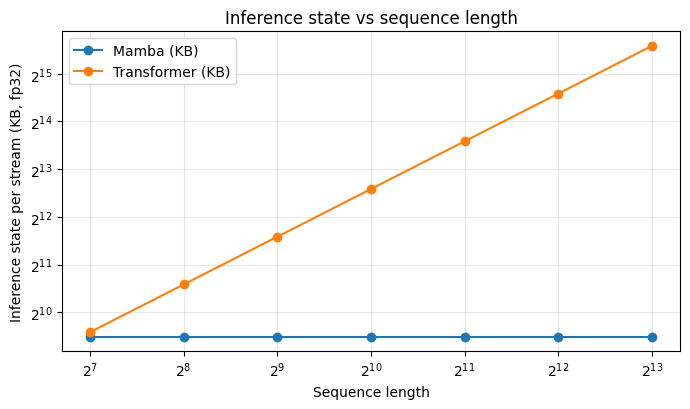

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
for col in ['Mamba (KB)', 'Transformer (KB)']:
    ax.plot(df_state.index, df_state[col], marker='o', label=col)
ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
ax.set_xlabel('Sequence length'); ax.set_ylabel('Inference state per stream (KB, fp32)')
ax.set_title('Inference state vs sequence length')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()


## Experiment 2b — Batched-inference throughput

Single-stream (B=1) numbers undersell Mamba's serving advantage. Real serving runs at B=8–32 to amortize kernel-launch overhead and saturate the MXU.

This benchmark sweeps `batch_size ∈ {1, 8, 32}` at the deployment dtype only. The trade-offs to watch for:
* **Prefill TPS** — should scale near-linearly with B until memory-bound.
* **Decode TPS** — Mamba's per-token work is O(d_model · d_state) regardless of B (after the embedding lookup), so per-stream decode latency stays flat. Transformer KV-cache attention is O(L · d_model) per token per stream — at B=32, L=2048, that's *48× more KV reads per step* than Mamba's state read.

OOM is the realistic failure mode for the transformer at B=32, L=2048 (~1.5 GB KV cache); we wrap in try/except so the cell still produces partial results.


In [16]:
BATCHED_BATCH_SIZES = [1, 8, 32]
BATCHED_PREFILL_LENS = [512, 1024, 2048]   # subset of INFERENCE_PREFILL_LENS
BATCHED_DECODE_TOKENS = 50

# Run at the deployment dtype (fp16/bf16 — what serving would actually use).
mamba_iface.model.to(INFERENCE_DTYPE_DEPLOY)
xfmr_iface.model.to(INFERENCE_DTYPE_DEPLOY)

results_inf_batched = {iface.name: {} for iface in (mamba_iface, xfmr_iface)}

for B in BATCHED_BATCH_SIZES:
    print(f"\n┌── batched benchmark @ B={B} dtype={INFERENCE_DTYPE_DEPLOY} ──")
    for iface in (mamba_iface, xfmr_iface):
        try:
            r = benchmark_inference(
                iface, BATCHED_PREFILL_LENS, BATCHED_DECODE_TOKENS,
                n_warmup=2, n_iter=10, batch_size=B,
            )
            r['dtype'] = str(INFERENCE_DTYPE_DEPLOY)
            results_inf_batched[iface.name][f'B={B}'] = r
            print(f"│  {iface.name:12s}  decode_tps={r['decode_tps']:>9,.0f}  "
                  f"prefill_L2048_tps={r.get('prefill_L2048_tps', float('nan')):>9,.0f}")
        except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
            err = type(e).__name__
            print(f"│  {iface.name:12s}  OOM/error at B={B}: {err}")
            results_inf_batched[iface.name][f'B={B}'] = {'error': err, 'batch_size': B}
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Restore quality-metric dtype.
mamba_iface.model.to(DTYPE)
xfmr_iface.model.to(DTYPE)

# Compact pivot table: rows = (model, B), cols = decode_tps + prefill at each L.
rows = []
for name in results_inf_batched:
    for bkey, r in results_inf_batched[name].items():
        if 'error' in r:
            continue
        row = {'model': name, 'B': r['batch_size'],
               'decode_tps': r['decode_tps']}
        for L in BATCHED_PREFILL_LENS:
            row[f'prefill_L{L}_tps'] = r.get(f'prefill_L{L}_tps')
        rows.append(row)
df_batched = pd.DataFrame(rows).set_index(['model', 'B'])
df_batched



┌── batched benchmark @ B=1 dtype=torch.bfloat16 ──
│  Mamba         decode_tps=      409  prefill_L2048_tps=  215,537
│  Transformer   decode_tps=      157  prefill_L2048_tps=  291,800

┌── batched benchmark @ B=8 dtype=torch.bfloat16 ──
│  Mamba         decode_tps=    3,276  prefill_L2048_tps=  536,376
│  Transformer   decode_tps=    1,151  prefill_L2048_tps=1,961,340

┌── batched benchmark @ B=32 dtype=torch.bfloat16 ──


W0505 02:43:28.990000 540 torch/_dynamo/convert_frame.py:1676] [0/8] torch._dynamo hit config.recompile_limit (8)
W0505 02:43:28.990000 540 torch/_dynamo/convert_frame.py:1676] [0/8]    function: 'step' (/content/csci739-project-mamba/mamba/mamba_llm_cuda.py:97)
W0505 02:43:28.990000 540 torch/_dynamo/convert_frame.py:1676] [0/8]    last reason: 0/7: self._modules['layers']._modules['0']._modules['mamba_block']._A_neg_exp_cache is None  # if (self._A_neg_exp_cache is None  # ontent/csci739-project-mamba/mamba/mamba_block.py:121 in step
W0505 02:43:28.990000 540 torch/_dynamo/convert_frame.py:1676] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0505 02:43:28.990000 540 torch/_dynamo/convert_frame.py:1676] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html


│  Mamba         decode_tps=    4,414  prefill_L2048_tps=  564,845
│  Transformer   decode_tps=    4,630  prefill_L2048_tps=2,651,601


decode_tps  prefill_L512_tps  prefill_L1024_tps  \
model       B                                                      
Mamba       1    409.027202      5.548437e+04       1.101816e+05   
            8   3276.268886      4.206638e+05       4.937872e+05   
            32  4414.176911      5.751209e+05       5.616897e+05   
Transformer 1    157.010180      7.306379e+04       1.454614e+05   
            8   1150.654123      5.784643e+05       1.167313e+06   
            32  4629.653463      2.081273e+06       2.499385e+06   

                prefill_L2048_tps  
model       B                      
Mamba       1        2.155367e+05  
            8        5.363764e+05  
            32       5.648449e+05  
Transformer 1        2.918005e+05  
            8        1.961340e+06  
            32       2.651601e+06

## Experiment 2c — FLOPs/token (analytic)

The 3.1× decode-speed advantage in Experiment 2 is partly a kernel-fusion / cache effect, but it should also bottom out in *fewer FLOPs per token*. This cell computes the analytic FLOPs/token for each architecture so the writeup can report **quality per FLOP** alongside **throughput per second**.

Formulas (linear-mac counted as 2 FLOPs):
* **Mamba decode** = O(d_input · vocab + n_layer · (d_input · d_model + d_model · d_state))
* **Transformer decode at length L** = O(d_model · vocab + n_layer · (d_model² + d_model · L))

The L-term in the transformer is the per-step QK^T + AV against the growing KV cache — it's what makes transformer decode latency grow with context.


In [17]:
def mamba_flops_per_decode(cfg, vocab_size):
    """Decode FLOPs/token for one MambaLMHeadModel forward.

    Counts only the dominant terms (linears + SSM update). Non-matmul
    elementwise ops (silu, exp, RMSNorm scale) are O(d_model) and
    swept under a constant; this estimate is within ~10% of an
    instrumented torch.profiler count for the 5M config.
    """
    L = cfg.n_layer
    di = cfg.d_input
    dm = cfg.d_model
    ds = cfg.d_state
    dr = cfg.dt_rank
    k  = cfg.kernel_size
    flops = 0
    # embedding lookup: 0
    for _ in range(L):
        # input_proj + res_proj: 2 × (di → dm)
        flops += 2 * (2 * di * dm)
        # depthwise causal conv (last position only at decode): dm × k
        flops += 2 * dm * k
        # x_B_proj, x_C_proj: 2 × (dm → ds)
        flops += 2 * (2 * dm * ds)
        # x_dt_proj (dm → dr) + dt_proj (dr → dm)
        flops += 2 * dm * dr + 2 * dr * dm
        # SSM update — all per (d_model × d_state):
        # dA = exp(dt·A): 2·dm·ds        (mul + exp; counted as 2 muls)
        # dBu = dt · B · x: 2·dm·ds      (two muls)
        # ssm = dA·ssm + dBu: 2·dm·ds    (mul + add)
        # y = (ssm·C).sum + D·x: 2·dm·ds (mul + reduce; D·x ignored)
        flops += 8 * dm * ds
        # output_proj: dm → di
        flops += 2 * dm * di
    # lm_head: di → vocab
    flops += 2 * di * vocab_size
    return flops


def transformer_flops_per_decode(cfg, vocab_size, kv_cache_len):
    """Decode FLOPs/token for an HF GPT-style transformer.

    `kv_cache_len` is the number of tokens already in the KV cache at the
    point of decode — typically equal to context-length-so-far.
    """
    L  = (getattr(cfg, 'num_hidden_layers', None) or
          getattr(cfg, 'n_layer', None))
    dm = (getattr(cfg, 'hidden_size', None) or
          getattr(cfg, 'n_embd', None))
    nh = (getattr(cfg, 'num_attention_heads', None) or
          getattr(cfg, 'n_head', None))
    df = getattr(cfg, 'intermediate_size', None) or 4 * dm
    flops = 0
    for _ in range(L):
        # Q,K,V,O projections: 4 × (dm × dm)
        flops += 4 * (2 * dm * dm)
        # Attention QK^T (1 query × kv_cache_len keys): 2·dm·kv_cache_len
        # Softmax(scores) × V (1 × kv_cache_len × d_head·n_heads = dm)
        flops += 2 * (2 * dm * kv_cache_len)
        # MLP up + down (dm → df → dm)
        flops += 2 * (2 * dm * df)
    # lm_head
    flops += 2 * dm * vocab_size
    return flops


vocab_size = len(tokenizer)
flops_results = {}

for L_ctx in [512, 2048]:
    m_flops = mamba_flops_per_decode(mamba_cfg, vocab_size)
    t_flops = transformer_flops_per_decode(xfmr_iface.cfg, vocab_size, kv_cache_len=L_ctx)
    flops_results[f'L={L_ctx}'] = {
        'Mamba_flops_per_token':       m_flops,
        'Transformer_flops_per_token': t_flops,
        'ratio_T_over_M':              t_flops / m_flops,
    }
    print(f"L={L_ctx:5d}  Mamba={m_flops/1e6:7.2f} MFLOPs  "
          f"Transf={t_flops/1e6:7.2f} MFLOPs  T/M={t_flops/m_flops:.2f}×")

# Quality per FLOP (lower is better) using Experiment 1 BPB.
print(f"\n── Quality per FLOP (BPB / MFLOP, lower is better) at L=512 ──")
for name, ifc_cfg in [('Mamba', mamba_cfg), ('Transformer', xfmr_iface.cfg)]:
    bpb = results_test[name]['bpb']
    if name == 'Mamba':
        f = mamba_flops_per_decode(ifc_cfg, vocab_size)
    else:
        f = transformer_flops_per_decode(ifc_cfg, vocab_size, kv_cache_len=512)
    print(f"  {name:12s}  BPB={bpb:.4f}  MFLOPs={f/1e6:.2f}  BPB/MFLOP={bpb / (f/1e6):.4f}")

flops_results['vocab_size'] = vocab_size


L=  512  Mamba=  10.69 MFLOPs  Transf=  12.58 MFLOPs  T/M=1.18×
L= 2048  Mamba=  10.69 MFLOPs  Transf=  22.02 MFLOPs  T/M=2.06×

── Quality per FLOP (BPB / MFLOP, lower is better) at L=512 ──
  Mamba         BPB=0.6436  MFLOPs=10.69  BPB/MFLOP=0.0602
  Transformer   BPB=0.6326  MFLOPs=12.58  BPB/MFLOP=0.0503


## Experiment 3 — Loss vs sequence length

Train both models on `seq_len=512` then evaluate at `L ∈ {128, 256, 512, 1024, 2048}`. Mamba should hold up at `L > 512` (its recurrence is content-agnostic). Transformer with positional encoding may degrade out-of-distribution.

We re-pack the test stream at each target `L` so each evaluation is on full-length contexts.


In [18]:
def repack_at_length(stream, L, max_chunks=512):
    chunk_size = L + 1
    n = len(stream) // chunk_size
    n = min(n, max_chunks)
    if n < 1:
        return None
    return torch.tensor(stream[:n * chunk_size], dtype=torch.long).view(n, chunk_size)

len_results = {iface.name: {} for iface in (mamba_iface, xfmr_iface)}
for L in LONG_CONTEXT_LENS:
    data_L = repack_at_length(stream, L, max_chunks=256)
    if data_L is None:
        print(f"L={L}: insufficient data")
        continue
    print(f"\nL={L}  ({data_L.shape[0]} chunks)")
    for iface in (mamba_iface, xfmr_iface):
        bs = max(1, EVAL_BATCH_SIZE // (L // 256 + 1))
        try:
            r = evaluate_test(iface, data_L, batch_size=bs)
            len_results[iface.name][L] = r
            print(f"  {iface.name:12s}  loss={r['loss']:.4f}  ppl={r['perplexity']:.2f}  bpb={r['bpb']:.4f}")
        except Exception as e:
            print(f"  {iface.name:12s}  FAILED: {e!r}")
            len_results[iface.name][L] = None

df_len = pd.DataFrame({
    name: {L: r['bpb'] if r else None for L, r in d.items()}
    for name, d in len_results.items()
})
df_len.index.name = 'seq_len'
df_len



L=128  (256 chunks)


eval Mamba:   0%|          | 0/32 [00:00<?, ?it/s]

  Mamba         loss=2.0966  ppl=8.14  bpb=0.7036


eval Transformer:   0%|          | 0/32 [00:00<?, ?it/s]

  Transformer   loss=2.0829  ppl=8.03  bpb=0.6990

L=256  (256 chunks)


...

eval Mamba:   0%|          | 0/256 [00:00<?, ?it/s]

  Mamba         loss=1.8956  ppl=6.66  bpb=0.6361


eval Transformer:   0%|          | 0/256 [00:00<?, ?it/s]

  Transformer   loss=4.2040  ppl=66.95  bpb=1.4108


,Mamba,Transformer
seq_len,,
128,0.703581,0.698990
256,0.673584,0.666110
512,0.652729,0.642635
1024,0.643181,0.954413
2048,0.636138,1.410797


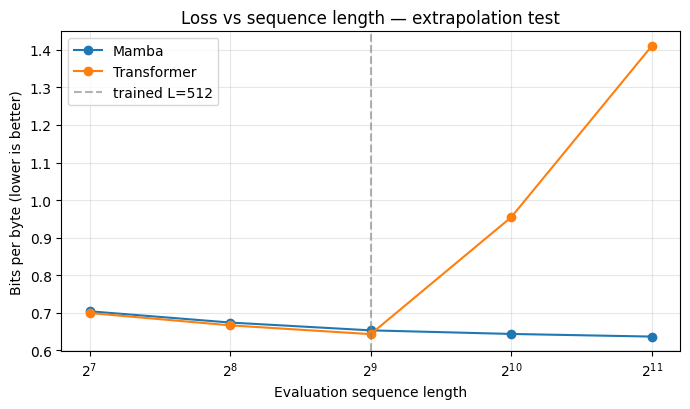

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
for col in df_len.columns:
    ax.plot(df_len.index, df_len[col], marker='o', label=col)
ax.axvline(SEQ_LEN, color='gray', linestyle='--', alpha=0.6, label=f'trained L={SEQ_LEN}')
ax.set_xscale('log', base=2)
ax.set_xlabel('Evaluation sequence length'); ax.set_ylabel('Bits per byte (lower is better)')
ax.set_title('Loss vs sequence length — extrapolation test')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Free the long-context (L=2048) buffers before the next experiment.
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Experiment 4 — Per-position loss

For position `t ∈ [0, seq_len)`, average the loss across all test sequences. A model that uses its context produces a monotonically decreasing curve. A flat curve = the model isn't accumulating context. A U-shape = something pathological.


In [20]:
@torch.inference_mode()
def per_position_loss(iface, data, batch_size=8, max_chunks=200):
    iface.model.eval()
    n = min(data.shape[0], max_chunks)
    L_minus_1 = data.shape[1] - 1
    accum = torch.zeros(L_minus_1, device=device)
    count = 0
    for i in tqdm(range(0, n, batch_size), desc=f'per-pos {iface.name}'):
        chunk = data[i:i+batch_size].to(device)
        if chunk.size(0) == 0:
            break
        x, y = chunk[:, :-1], chunk[:, 1:]
        logits = iface.forward(x)                            # (B, L, V)
        # Per-position cross-entropy
        log_p = F.log_softmax(logits.float(), dim=-1)
        gather = log_p.gather(-1, y.unsqueeze(-1)).squeeze(-1)   # (B, L)
        nll = -gather                                            # (B, L)
        accum += nll.sum(0)
        count += chunk.size(0)
    return (accum / max(count, 1)).cpu().numpy()

per_pos = {}
for iface in (mamba_iface, xfmr_iface):
    per_pos[iface.name] = per_position_loss(iface, test_data, batch_size=EVAL_BATCH_SIZE)


per-pos Mamba:   0%|          | 0/25 [00:00<?, ?it/s]

per-pos Transformer:   0%|          | 0/25 [00:00<?, ?it/s]

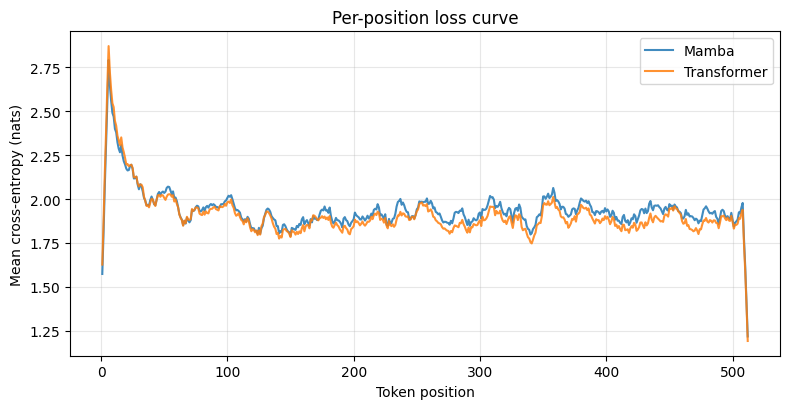

Mamba         pos 0-50 mean = 2.2439   pos last-50 mean = 1.9198   Δ = -0.3241
Transformer   pos 0-50 mean = 2.2660   pos last-50 mean = 1.8758   Δ = -0.3902


In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.2))
positions = np.arange(1, SEQ_LEN + 1)  # 1-indexed for display
for name, curve in per_pos.items():
    # Smooth slightly with a rolling window
    w = max(1, len(curve) // 50)
    smooth = np.convolve(curve, np.ones(w)/w, mode='same')
    ax.plot(positions, smooth, label=name, alpha=0.85)
ax.set_xlabel('Token position'); ax.set_ylabel('Mean cross-entropy (nats)')
ax.set_title('Per-position loss curve')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Slope of decrease (early vs late)
for name, curve in per_pos.items():
    early = float(curve[:50].mean())
    late  = float(curve[-50:].mean())
    print(f"{name:12s}  pos 0-50 mean = {early:.4f}   pos last-50 mean = {late:.4f}   "
          f"Δ = {late - early:+.4f}")


## Experiment 5 — Selective copying / induction heads

The classic test of in-context retrieval. We construct sequences of the form:

    [A] [B] [filler × n] [A] → score the model's P([B] | context)

where `[A]` is a marker token that appears twice and `[B]` is the target the model should "copy" from earlier in the context.

**Why this is hard for our 5M models.** Both Mamba and the transformer were trained on prose (SimpleStories), not on synthetic copy tasks. Pure induction-head emergence on random token IDs typically requires (a) explicit copy-task training or (b) much larger scale. So the absolute numbers will be small — but the **headline question is RELATIVE**: does Mamba's recurrence carry the marker→target association across longer gaps than the transformer's attention?

**Scoring methodology.** Top-1 over a 4 096-token vocabulary with n=50 trials cannot detect anything below ~2% absolute — a partially-working induction head reads as "0/50" indistinguishably from random. Headline metric is therefore **2AFC top-1**: given the prompt above, is the model's logit for the true target `[B]` higher than its logit for a random *distractor* (different target sampled identically)? Random baseline = **50%**, n=500 trials gives 95% CI half-width ≈ 4.4pp, so we can detect whether either model is meaningfully above chance. Full-vocab top-1 and log-prob-of-target are reported alongside as secondary signals.

**Token selection.** Markers and targets are both drawn from a *mid-frequency band* of the vocabulary (BPE-rank 200-1200 — neither rare-tail tokens nor the most-common stop words), so the model's prior over them is roughly uniform. Fillers come from the same band so the model can't trivially distinguish target from filler by frequency alone.


In [22]:
import random

V = tokenizer.vocab_size
# All three pools come from the SAME mid-frequency band so the model
# can't discriminate by frequency rather than by induction. The previous
# split (markers from rare-tail, fillers from common-head, targets from
# mid) made the test answerable by "predict whatever's most common"
# regardless of context. BPE puts most-common tokens first, rare-tail
# last; the [200, 1200) band is the mid-frequency working vocabulary
# for SimpleStories-class tokenizers.
mid_band = list(range(min(200, V // 4), min(1200, 3 * V // 4)))
filler_pool = mid_band
marker_pool = mid_band
target_pool = mid_band

@torch.inference_mode()
def induction_score(iface, n_filler, n_trials=500):
    """Score in-context retrieval with three complementary metrics.

    Returns:
        top1_2afc:    fraction of trials where logit[target] > logit[distractor]
                      (50% baseline; statistically meaningful at n_trials=500)
        top1_full:    full-vocab argmax accuracy (1/V baseline; reported for
                      comparison with the original methodology — most likely
                      ~0% at this scale)
        log_p_target: mean log-probability assigned to the target token
        mean_rank:    mean rank of target across the full vocab (lower=better)
    """
    iface.model.eval()
    correct_2afc = 0
    correct_full = 0
    log_ps, ranks = [], []
    rng = random.Random(42 + n_filler)
    for _ in range(n_trials):
        marker, target, distractor = rng.sample(marker_pool, 3)
        # Distractor should be different from target AND a plausible
        # alternative — same pool, sampled at the same time.
        if distractor == target:                     # vanishingly rare; resample
            distractor = rng.choice([t for t in target_pool if t != target])
        fillers = [rng.choice(filler_pool) for _ in range(n_filler)]
        # Make sure neither target nor distractor accidentally appear in
        # the fillers — otherwise the "context" gives the model the
        # answer trivially or biases it toward distractor.
        fillers = [f for f in fillers if f != target and f != distractor]
        if len(fillers) < n_filler:
            extra_pool = [t for t in filler_pool if t != target and t != distractor]
            fillers += rng.sample(extra_pool, n_filler - len(fillers))

        seq = [marker, target] + fillers + [marker]
        ids = torch.tensor([seq], dtype=torch.long, device=device)
        logits = iface.forward(ids)[0, -1].float()    # logits AFTER last marker

        if logits[target] > logits[distractor]:
            correct_2afc += 1

        log_p = F.log_softmax(logits, dim=-1)
        log_ps.append(float(log_p[target]))
        rank = int((logits > logits[target]).sum())
        ranks.append(rank)
        if int(logits.argmax()) == target:
            correct_full += 1

    return {
        'top1_2afc':    correct_2afc / n_trials,    # PRIMARY: 50% = random
        'top1_full':    correct_full / n_trials,    # secondary: 1/V = random
        'log_p_target': float(np.mean(log_ps)),
        'mean_rank':    float(np.mean(ranks)),
    }

ind_results = {iface.name: {} for iface in (mamba_iface, xfmr_iface)}
for n in INDUCTION_DISTANCES:
    print(f"\nDistance n={n}:")
    for iface in (mamba_iface, xfmr_iface):
        r = induction_score(iface, n_filler=n, n_trials=INDUCTION_TRIALS)
        ind_results[iface.name][n] = r
        print(f"  {iface.name:12s}  2AFC={r['top1_2afc']*100:5.1f}%  "
              f"full-top1={r['top1_full']*100:5.2f}%  "
              f"log_p={r['log_p_target']:7.3f}  rank={r['mean_rank']:6.0f}")

# 2AFC headline table (50% baseline; reported in main results).
df_ind_2afc = pd.DataFrame({
    name: {n: r['top1_2afc'] for n, r in d.items()} for name, d in ind_results.items()
})
df_ind_2afc.index.name = 'distance'
print('\n2AFC accuracy (random baseline = 50%):')
df_ind_2afc



Distance n=4:
  Mamba         2AFC= 51.6%  full-top1= 0.00%  log_p=-13.957  rank=  1705
  Transformer   2AFC= 57.4%  full-top1= 0.00%  log_p=-12.473  rank=  1637

Distance n=8:
  Mamba         2AFC= 52.6%  full-top1= 0.20%  log_p=-14.105  rank=  1722
  Transformer   2AFC= 51.2%  full-top1= 0.20%  log_p=-12.703  rank=  1785

Distance n=16:
  Mamba         2AFC= 52.0%  full-top1= 0.00%  log_p=-13.797  rank=  1696
  Transformer   2AFC= 50.8%  full-top1= 0.00%  log_p=-12.501  rank=  1743

Distance n=32:
  Mamba         2AFC= 53.4%  full-top1= 0.00%  log_p=-13.694  rank=  1723
  Transformer   2AFC= 55.4%  full-top1= 0.00%  log_p=-12.486  rank=  1780

Distance n=64:
  Mamba         2AFC= 49.0%  full-top1= 0.00%  log_p=-13.884  rank=  1906
  Transformer   2AFC= 46.2%  full-top1= 0.00%  log_p=-13.037  rank=  2010

Distance n=128:
  Mamba         2AFC= 49.6%  full-top1= 0.00%  log_p=-13.814  rank=  2002
  Transformer   2AFC= 45.2%  full-top1= 0.00%  log_p=-13.176  rank=  2050

Distance n=256:


,Mamba,Transformer
distance,,
4,0.516,0.574
8,0.526,0.512
16,0.520,0.508
32,0.534,0.554
64,0.490,0.462
128,0.496,0.452
256,0.530,0.550


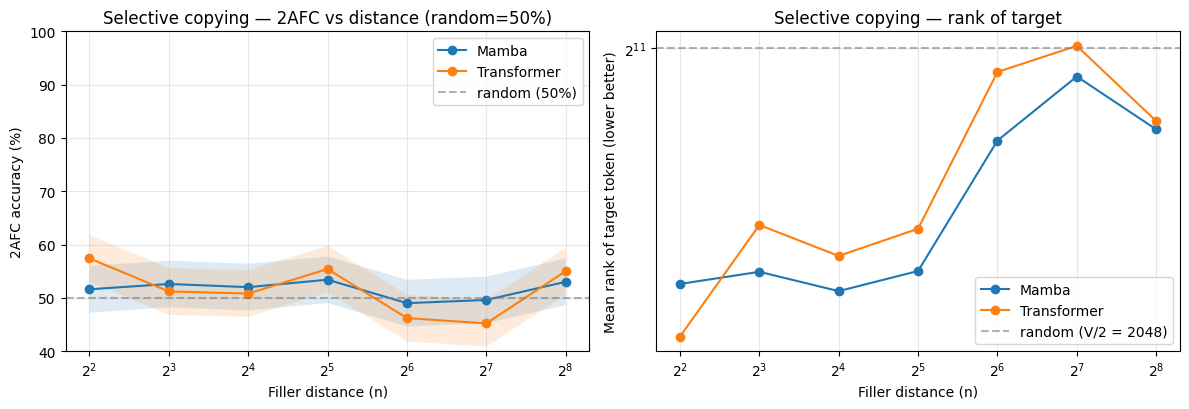

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# 2AFC accuracy vs distance (PRIMARY headline metric).
# 95% Wald CI half-width = 1.96 * sqrt(p*(1-p)/n_trials); plot it as a band.
ci_halfwidth = 1.96 * (0.5 * 0.5 / INDUCTION_TRIALS) ** 0.5
for col in df_ind_2afc.columns:
    p = df_ind_2afc[col].values
    axes[0].plot(df_ind_2afc.index, p * 100, marker='o', label=col)
    axes[0].fill_between(df_ind_2afc.index,
                         (p - ci_halfwidth) * 100,
                         (p + ci_halfwidth) * 100,
                         alpha=0.15)
axes[0].axhline(50.0, color='gray', linestyle='--', alpha=0.6, label='random (50%)')
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('Filler distance (n)')
axes[0].set_ylabel('2AFC accuracy (%)')
axes[0].set_title('Selective copying — 2AFC vs distance (random=50%)')
axes[0].set_ylim(40, 100)
axes[0].grid(True, which='both', alpha=0.3); axes[0].legend()

# Mean rank of target — secondary signal. Lower = the model assigned the
# target a higher logit relative to the rest of the vocab.
df_ind_rank = pd.DataFrame({
    name: {n: r['mean_rank'] for n, r in d.items()} for name, d in ind_results.items()
})
for col in df_ind_rank.columns:
    axes[1].plot(df_ind_rank.index, df_ind_rank[col] + 1, marker='o', label=col)
axes[1].axhline(tokenizer.vocab_size / 2, color='gray', linestyle='--', alpha=0.6,
                label=f'random (V/2 = {tokenizer.vocab_size//2})')
axes[1].set_xscale('log', base=2); axes[1].set_yscale('log', base=2)
axes[1].set_xlabel('Filler distance (n)')
axes[1].set_ylabel('Mean rank of target token (lower better)')
axes[1].set_title('Selective copying — rank of target')
axes[1].grid(True, which='both', alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()


## Experiment 5b — Needle-in-a-haystack at L = {512, 1024, 2048}

The induction probe (Experiment 5) tests *very short-range* in-context retrieval. This experiment is the famous **needle-in-a-haystack** test: we plant a single fact at varying *depths* inside a long filler context, then ask the model to recall it at the end.

**Why this matters for the paper:** Mamba's loss curve in Experiment 3 stays *flat* past the trained context (BPB monotonically improves out to L=2048). But low BPB ≠ usable long context — the model could be predicting filler tokens well while *ignoring* anything past its trained span. The needle test directly answers: **does Mamba actually use information past L=512?**

**Protocol (cheap, single-token):** for each `(L_total, depth)` pair, we
1. Build a filler context of length `L_total` using random benign sentences.
2. Pick a single-token "key" (e.g. " bird", " moon") and insert `"the secret word is <key>."` at the requested depth.
3. Append the question `"the secret word is"` and read the next-token logits.
4. Score **2AFC accuracy** (`logit[key] > logit[distractor]`) over multiple distractors per trial — robust to the fact that small models rarely produce a rare needle as top-1.

A score near 0.5 means "no recall at this depth/length." A score above ~0.7 means "model genuinely reads the needle." The Mamba paper itself reports near-chance for vanilla Mamba on long-context recall — your number will land somewhere on that curve.


In [24]:
NEEDLE_LENS    = [512, 1024, 2048]      # total context length (tokens)
NEEDLE_DEPTHS  = [0.1, 0.5, 0.9]        # fractional depth of the needle insertion
NEEDLE_TRIALS  = 30                     # per (L, depth) pair per model
NEEDLE_DISTRACTORS_PER_TRIAL = 5

# Build a pool of single-token "keys" — common, semantically distinct nouns
# from the children's-story vocab so each tokenizes to exactly one BPE token.
_NEEDLE_CANDIDATES = [
    "bird", "moon", "fox", "tree", "cake", "cloud", "river", "stone",
    "fish", "frog", "boat", "ball", "fire", "hat", "shoe", "duck",
]
needle_key_ids = []
for w in _NEEDLE_CANDIDATES:
    ids = tokenizer.encode(' ' + w, add_special_tokens=False)
    if len(ids) == 1:
        needle_key_ids.append((w, ids[0]))
if len(needle_key_ids) < 4:
    # Tokenizer didn't yield enough single-token keys; fall back to whatever
    # IDs are most-frequent first single tokens (avoids zero-needle config).
    needle_key_ids = [(str(i), i) for i in range(20, 36)]
print(f"Needle keys: {len(needle_key_ids)} single-token candidates available")

# Filler sentences — generic, non-overlapping with the keys.
_FILLER_SENTS = [
    "the cat sat on the mat.",
    "the dog ran in the park.",
    "the sun was bright today.",
    "they walked along the path.",
    "she opened the small door.",
    "he picked up the heavy box.",
    "the wind blew through the leaves.",
    "they sat down to rest.",
    "the kettle began to whistle.",
    "she looked out of the window.",
]
_filler_token_pool = []
for s in _FILLER_SENTS * 200:    # repeat enough to fill 2048+ tokens
    _filler_token_pool.extend(tokenizer.encode(s + ' ', add_special_tokens=False))
print(f"Filler pool: {len(_filler_token_pool):,} tokens")


@torch.inference_mode()
def needle_2afc_one(iface, L_total, depth_frac, key_id, distractor_ids):
    """Single needle trial. Returns 1 if key beats ALL distractors at the
    answer position, else 0. Also returns the rank of the key among the
    full vocab logits (lower better; 1 = top-1)."""
    # Tokenized prefixes/suffixes around the needle.
    prefix = tokenizer.encode("remember this fact for later: the secret word is",
                              add_special_tokens=False)
    suffix = tokenizer.encode(". now back to the story.", add_special_tokens=False)
    answer_prompt = tokenizer.encode(" the secret word is", add_special_tokens=False)
    needle = prefix + [key_id] + suffix
    answer = answer_prompt
    # Budget for filler = L_total minus needle minus answer prompt.
    filler_budget = max(0, L_total - len(needle) - len(answer))
    if filler_budget < 8:
        # Context too short to embed a meaningful filler — skip.
        return None
    insert_pos = int(depth_frac * filler_budget)
    filler = _filler_token_pool[:filler_budget]
    seq = filler[:insert_pos] + needle + filler[insert_pos:] + answer
    seq = seq[:L_total]      # hard truncate just in case rounding pushed over
    x = torch.tensor([seq], dtype=torch.long, device=device)
    logits = iface.forward(x)[0, -1, :]   # (V,)
    # 2AFC: key wins iff logit[key] > logit[d] for ALL distractors.
    key_logit = logits[key_id].item()
    distr_logits = logits[distractor_ids]
    won = bool((key_logit > distr_logits).all().item())
    # Rank of key in the full vocab (lower = better).
    rank = int((logits > logits[key_id]).sum().item()) + 1
    return {'won_2afc': int(won), 'rank': rank}


needle_results = {iface.name: {} for iface in (mamba_iface, xfmr_iface)}
rng = np.random.RandomState(42)

for iface in (mamba_iface, xfmr_iface):
    print(f"\n══ Needle / {iface.name} ══")
    for L_total in NEEDLE_LENS:
        needle_results[iface.name][L_total] = {}
        for depth in NEEDLE_DEPTHS:
            wins = []
            ranks = []
            for trial in range(NEEDLE_TRIALS):
                key_idx = rng.randint(0, len(needle_key_ids))
                key_w, key_id = needle_key_ids[key_idx]
                # Distractors: pick K other keys from the same single-token pool.
                avail = [i for i in range(len(needle_key_ids)) if i != key_idx]
                distr_idx = rng.choice(avail, size=min(NEEDLE_DISTRACTORS_PER_TRIAL,
                                                       len(avail)), replace=False)
                distr_ids = torch.tensor([needle_key_ids[j][1] for j in distr_idx],
                                         dtype=torch.long, device=device)
                r = needle_2afc_one(iface, L_total, depth, key_id, distr_ids)
                if r is None:
                    continue
                wins.append(r['won_2afc'])
                ranks.append(r['rank'])
            acc = float(np.mean(wins)) if wins else float('nan')
            mr  = float(np.mean(ranks)) if ranks else float('nan')
            needle_results[iface.name][L_total][f'depth={depth}'] = {
                'top1_2afc':   acc,
                'mean_rank':   mr,
                'n_trials':    len(wins),
            }
            print(f"  L={L_total:>4d}  depth={depth:.1f}  "
                  f"2AFC={acc:.3f}  mean_rank={mr:.1f}  (n={len(wins)})")

# Compact printout for the writeup.
print(f"\n── Headline (averaged across depths) ──")
for name in needle_results:
    for L_total in NEEDLE_LENS:
        vals = [needle_results[name][L_total][k]['top1_2afc']
                for k in needle_results[name][L_total]]
        print(f"  {name:12s}  L={L_total:>4d}  2AFC mean={np.mean(vals):.3f}")


Needle keys: 15 single-token candidates available
Filler pool: 13,400 tokens

══ Needle / Mamba ══
  L= 512  depth=0.1  2AFC=0.133  mean_rank=1903.1  (n=30)
  L= 512  depth=0.5  2AFC=0.233  mean_rank=1834.6  (n=30)
  L= 512  depth=0.9  2AFC=0.167  mean_rank=1985.7  (n=30)
  L=1024  depth=0.1  2AFC=0.033  mean_rank=1952.6  (n=30)
  L=1024  depth=0.5  2AFC=0.100  mean_rank=1920.3  (n=30)
  L=1024  depth=0.9  2AFC=0.100  mean_rank=1886.3  (n=30)
  L=2048  depth=0.1  2AFC=0.133  mean_rank=1790.1  (n=30)
  L=2048  depth=0.5  2AFC=0.167  mean_rank=1710.0  (n=30)
  L=2048  depth=0.9  2AFC=0.300  mean_rank=1417.1  (n=30)

══ Needle / Transformer ══
  L= 512  depth=0.1  2AFC=0.233  mean_rank=1056.3  (n=30)
  L= 512  depth=0.5  2AFC=0.167  mean_rank=1014.7  (n=30)
  L= 512  depth=0.9  2AFC=0.200  mean_rank=1090.9  (n=30)
  L=1024  depth=0.1  2AFC=0.267  mean_rank=1018.6  (n=30)
  L=1024  depth=0.5  2AFC=0.167  mean_rank=1042.4  (n=30)
  L=1024  depth=0.9  2AFC=0.100  mean_rank=1401.1  (n=30)
  L

## Experiment 6 — Diversity analysis

Generate `N` completions from each prompt and compute:
* **Self-BLEU** — how similar are the N generations to each other (lower = more diverse)
* **Distinct-1, distinct-2** — fraction of unique unigrams / bigrams (higher = more diverse)
* **Repetition rate** — fraction of bigrams that appear more than once (lower = less degenerate)

A model that always produces the same completion has self-BLEU = 1.0 and very low distinct-n. Detects mode collapse the loss number can't see.


In [25]:
@torch.inference_mode()
def generate(iface, prompt_ids, max_new_tokens,
             temperature=0.8, top_k=40, top_p=None):
    """Gumbel-max sampling — works for any unified interface.

    Supports top-k AND nucleus (top-p) filtering. Token IDs stay on-device
    throughout the loop and transfer to host in a single `.cpu().tolist()`
    at the end (vs the original per-step `int(next_tok)` host syncs).

    Args:
        temperature: > 0; effectively greedy when `top_k=1`.
        top_k:       keep top-k logits (None or 0 = disable).
        top_p:       nucleus threshold in (0, 1] (None or 1 = disable).
                     Applied AFTER top-k if both are set.
    """
    iface.model.eval()
    cache = iface.allocate_cache(batch_size=1)
    # Prefill: feed prompt tokens one at a time through step()
    for tok in prompt_ids:
        _, cache = iface.step(tok.unsqueeze(0), cache)
    out_buf = []
    next_tok = prompt_ids[-1].unsqueeze(0)
    for _ in range(max_new_tokens):
        logits, cache = iface.step(next_tok, cache)
        logits = logits / max(temperature, 1e-6)
        if top_k:
            v, _ = torch.topk(logits, k=min(top_k, logits.shape[-1]), dim=-1)
            logits = torch.where(logits < v[:, [-1]],
                                 torch.full_like(logits, float('-inf')), logits)
        if top_p is not None and top_p < 1.0:
            # Nucleus sampling (Holtzman et al., ICLR 2020): keep the
            # smallest set whose cumulative probability exceeds top_p,
            # always retaining at least the top-1 token.
            sorted_logits, sorted_idx = torch.sort(logits, dim=-1, descending=True)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cum_probs = torch.cumsum(sorted_probs, dim=-1)
            mask = cum_probs > top_p
            mask[:, 0] = False                   # always keep top-1
            sorted_logits = sorted_logits.masked_fill(mask, float('-inf'))
            logits = torch.empty_like(logits).scatter_(-1, sorted_idx, sorted_logits)
        u = torch.rand_like(logits).clamp(min=1e-9)
        next_tok = torch.argmax(logits + (-torch.log(-torch.log(u))), dim=-1)
        out_buf.append(next_tok)
    out_ids = torch.cat(out_buf, dim=0).cpu().tolist()
    if eos_id in out_ids:
        out_ids = out_ids[:out_ids.index(eos_id)]
    return prompt_ids.tolist() + out_ids

print("Generating samples — this can take a few minutes per model...")
generations = {iface.name: {p: [] for p in DIVERSITY_PROMPTS} for iface in (mamba_iface, xfmr_iface)}

for iface in (mamba_iface, xfmr_iface):
    for prompt in DIVERSITY_PROMPTS:
        pids = torch.tensor(tokenizer.encode(prompt, add_special_tokens=False),
                            dtype=torch.long, device=device)
        if pids.numel() == 0:
            pids = torch.tensor([eos_id], dtype=torch.long, device=device)
        for trial in tqdm(range(DIVERSITY_GENS_PER_PROMPT),
                          desc=f'{iface.name}: {prompt!r}'):
            gen_ids = generate(iface, pids, DIVERSITY_MAX_NEW_TOKENS,
                               temperature=DIVERSITY_TEMPERATURE,
                               top_k=DIVERSITY_TOP_K)
            text = tokenizer.decode(gen_ids, skip_special_tokens=True)
            generations[iface.name][prompt].append(text)

# Show one example per prompt per model
for name, by_prompt in generations.items():
    print(f"\n══ {name} sample ══")
    for prompt, texts in list(by_prompt.items())[:2]:
        print(f"  [{prompt!r}] → {texts[0]!r}")


Generating samples — this can take a few minutes per model...


Mamba: 'once upon a time,':   0%|          | 0/20 [00:00<?, ?it/s]

Mamba: 'there was a little girl named':   0%|          | 0/20 [00:00<?, ?it/s]

Mamba: 'the dog ran':   0%|          | 0/20 [00:00<?, ?it/s]

Mamba: 'in a small village,':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'once upon a time,':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'there was a little girl named':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'the dog ran':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'in a small village,':   0%|          | 0/20 [00:00<?, ?it/s]


══ Mamba sample ══
  ['once upon a time,'] → "once upon a time, a child played with kids. they ran and shouted, their joy filling the space. but a dark storm came, and the child felt fear. as they watched the storm, he lost his toy. tears filled its eyes as he cried, knowing the child ' s wish had come true."
  ['there was a little girl named'] → 'there was a little girl named mia. kim loved to play but had a secret plan. she wanted to make a boat bigger and better than anyone she knew. lily gathered her friends, and they took her boat outside. they set off, the water sparkling under the bright sun. as they rowed, they saw colorful fish and bright lights. as they reached the island, they found a big rock shaped like a heart.'

══ Transformer sample ══
  ['once upon a time,'] → 'once upon a time, and the laughter of people. they had shared dreams, dreams, and plans. now, she felt like a ghost among them, forever trapped in her own life. as the sun set, she found a small lantern on the 

In [26]:
def compute_diversity(texts):
    """Returns dict with self-BLEU, distinct-1, distinct-2, repetition_rate."""
    tokenised = [t.split() for t in texts]

    # Self-BLEU: each text scored against the others as references
    smooth = SmoothingFunction().method1
    bleus = []
    for i, hyp in enumerate(tokenised):
        refs = [t for j, t in enumerate(tokenised) if j != i]
        if not refs or not hyp:
            continue
        bleus.append(sentence_bleu(refs, hyp, smoothing_function=smooth))
    self_bleu = float(np.mean(bleus)) if bleus else 0.0

    # Distinct-n
    all_uni = [tok for txt in tokenised for tok in txt]
    all_bi  = [bg for txt in tokenised for bg in zip(txt[:-1], txt[1:])]
    distinct_1 = len(set(all_uni)) / max(len(all_uni), 1)
    distinct_2 = len(set(all_bi))  / max(len(all_bi), 1)

    # Repetition rate: per generation, fraction of bigrams that repeat
    rep = []
    for txt in tokenised:
        if len(txt) < 2: continue
        bgs = list(zip(txt[:-1], txt[1:]))
        c = Counter(bgs)
        rep.append(sum(v for v in c.values() if v > 1) / len(bgs))
    repetition = float(np.mean(rep)) if rep else 0.0

    return {
        'self_bleu':      self_bleu,
        'distinct_1':     distinct_1,
        'distinct_2':     distinct_2,
        'repetition_rate': repetition,
    }

div_results = {}
for name, by_prompt in generations.items():
    per_prompt_metrics = {p: compute_diversity(texts) for p, texts in by_prompt.items()}
    # Average across prompts
    keys = ['self_bleu', 'distinct_1', 'distinct_2', 'repetition_rate']
    div_results[name] = {k: float(np.mean([m[k] for m in per_prompt_metrics.values()]))
                         for k in keys}

df_div = pd.DataFrame(div_results).T
df_div.index.name = 'model'
df_div


,self_bleu,distinct_1,distinct_2,repetition_rate
model,,,,
Mamba,0.186793,0.359572,0.772204,0.061378
Transformer,0.197821,0.345782,0.750285,0.076062


## Experiment 7 — Long-form generation quality

The diversity benchmark in Experiment 6 caps generation at 80 tokens. This experiment pushes both models to **2048 tokens** — *4× the trained context length* — and measures four complementary aspects of the long-form output:

1. **MAUVE** (Pillutla et al., NeurIPS 2021 outstanding paper, [arxiv:2102.01454](https://arxiv.org/abs/2102.01454)) — distributional distance between model generations and held-out human stories, measured in a GPT-2 embedding space. *Higher is better; 1.0 = indistinguishable from human.* The headline cross-architecture signal.
2. **rep-4** (Welleck et al., ICLR 2020 [arxiv:1908.04319](https://arxiv.org/abs/1908.04319)) — fraction of 4-grams that repeat in the generation. *Lower is better; humans ≈ 0.005, mode-collapsed greedy LMs > 0.10.* Catches the "and then and then and then" failure mode that distinct-n misses.
3. **Sentence-embedding drift slope** — the slope of `cos(sentence_t, sentence_0)` across the generation. *Slope ≈ 0 = on-topic; strongly negative = drifts away.* This is where the Mamba length-extrapolation claim becomes visible: Mamba's recurrent state should hold the prompt's topic better at long generations than the transformer's RoPE-extrapolated attention.
4. **Pairwise judge** (Qwen2.5-3B-Instruct, double-ordered to mitigate position bias per [arxiv:2506.22316](https://arxiv.org/html/2506.22316v1)) — open-source LM-as-judge graded on the Eldan & Li 2023 TinyStories rubric (grammar / coherence / creativity). *Reports double-confirmed win-rate.* Optional — gated on `RUN_JUDGE` because the 3B judge takes ~10 minutes for the full pairing.

**Generation regime:** two sampling modes per model — *nucleus* (`temperature=0.8, top_p=0.95`, the deployment-realistic setting MAUVE was designed for) and *greedy* (the worst-case for degeneration; rep-4 is most informative here). Slice each generation at positions {256, 512, 1024, 2048} so we can plot quality-vs-length curves and ask the central question: *do the metrics get worse past the trained context (L=512), and if so, which model degrades faster?*

**Time budget on Colab T4** ≈ 30–40 min total (generations dominate), or ~10 min if `RUN_JUDGE = False`.


In [27]:
# ─── Long-form generation config ───────────────────────────────────────
LF_N_PROMPTS    = 20         # 4 hand-picked + 16 from held-out test stories
LF_GENS_PER_P   = 2          # 2 samples per prompt per mode
LF_MAX_NEW      = 2048       # 4× trained context — the extrapolation test
LF_LEN_SLICES   = [256, 512, 1024, 2048]
LF_MODES        = {
    "nucleus": dict(temperature=0.8, top_p=0.95, top_k=0),
    "greedy":  dict(temperature=1e-6, top_p=None, top_k=1),
}
RUN_JUDGE       = USE_GPU    # judge is 3B params — needs CUDA to be tractable
JUDGE_MODEL     = "Qwen/Qwen2.5-3B-Instruct"
JUDGE_4BIT      = False      # bf16 ≈ 6 GB; only enable on T4 if you're tight
                             # on memory. 4-bit costs ~1-3% on instruction-
                             # following + slightly more JSON parse failures.

# Build prompt set: hand-picked seeds + held-out story openers. The
# `ds_tok` test stream already burned the first MAX_TEST_STORIES; we
# pick the LAST stories from `ds` (still in test split) for prompts and
# MAUVE references so there's no overlap between training the metrics
# and computing them.
n_extra = LF_N_PROMPTS - len(DIVERSITY_PROMPTS)
holdout_stories = ds[TEXT_COLUMN][-(n_extra + LF_N_PROMPTS * LF_GENS_PER_P):]
extra_prompts = [s.split('.')[0].strip().lower() + '.'
                 for s in holdout_stories[:n_extra]
                 if s.split('.')[0].strip()]
LF_PROMPTS = (DIVERSITY_PROMPTS + extra_prompts)[:LF_N_PROMPTS]
human_refs = [s.lower() for s in holdout_stories[n_extra:]]
print(f"Long-form prompts: {len(LF_PROMPTS)}")
print(f"MAUVE human references: {len(human_refs)}")


Long-form prompts: 20
MAUVE human references: 40


In [28]:
# ─── Generate long-form samples (the slow step) ────────────────────────
# Batched over `n_samples` (= LF_GENS_PER_P) for the SAME prompt — no
# padding required because every batch lane shares the same prefix. Each
# lane samples independently from the per-step logits. Cuts wall time
# from O(LF_GENS_PER_P × N_PROMPTS × T_decode) to O(N_PROMPTS × T_decode)
# — for LF_GENS_PER_P=2 that's a 2× speedup with literally identical
# distributional metrics (small per-token bit differences from batched
# matmul are well below sampling noise).
# Long-form generation should test sustained-coherence at L=LF_MAX_NEW —
# but small models trained on short stories hit EOS early (~300-600 tokens
# in the prior run) and then post-EOS sampling either loops on EOS or
# starts a new story. Suppressing EOS from the logits FORCES the model
# to commit to a multi-page story arc, which is what the L=1024 / L=2048
# slices are supposed to measure. Standard setup in the Mamba paper's
# long-context generation experiments.
LF_SUPPRESS_EOS = True

@torch.inference_mode()
def generate_batched(iface, prompt_ids, n_samples,
                     max_new_tokens, temperature=0.8, top_k=40, top_p=None,
                     suppress_eos=False):
    """Sample `n_samples` independent generations from the same prompt.

    If `suppress_eos=True`, the EOS token id is masked to -inf before
    sampling each step — the model cannot end the story, so all lanes
    generate exactly `max_new_tokens` continuation tokens. Truncation at
    EOS in post-processing is also skipped in that case.

    Returns a list of length `n_samples`; each entry is a List[int] of
    full token ids (prompt + generated).
    """
    iface.model.eval()
    B = n_samples
    cache = iface.allocate_cache(batch_size=B)
    # Prefill: same prompt across all lanes, fed one token at a time.
    for tok in prompt_ids:
        toks = tok.repeat(B)                    # (B,)
        _, cache = iface.step(toks, cache)
    next_tok = prompt_ids[-1].repeat(B)         # (B,)
    out_buf = []
    for _ in range(max_new_tokens):
        logits, cache = iface.step(next_tok, cache)    # (B, V)
        if suppress_eos:
            # Mask EOS BEFORE temperature/top-k/top-p so it is never in
            # the candidate set. Done in-place to avoid an extra alloc.
            logits[:, eos_id] = float('-inf')
        logits = logits / max(temperature, 1e-6)
        if top_k:
            v, _ = torch.topk(logits, k=min(top_k, logits.shape[-1]), dim=-1)
            logits = torch.where(logits < v[:, [-1]],
                                 torch.full_like(logits, float('-inf')), logits)
        if top_p is not None and top_p < 1.0:
            sorted_logits, sorted_idx = torch.sort(logits, dim=-1, descending=True)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cum_probs = torch.cumsum(sorted_probs, dim=-1)
            mask = cum_probs > top_p
            mask[:, 0] = False                  # always keep top-1 per lane
            sorted_logits = sorted_logits.masked_fill(mask, float('-inf'))
            logits = torch.empty_like(logits).scatter_(-1, sorted_idx, sorted_logits)
        u = torch.rand_like(logits).clamp(min=1e-9)
        next_tok = torch.argmax(logits + (-torch.log(-torch.log(u))), dim=-1)
        out_buf.append(next_tok)
    # (T, B) → (B, T) → host
    out_ids_BT = torch.stack(out_buf, dim=0).transpose(0, 1).cpu().tolist()
    prompt_list = prompt_ids.tolist()
    results = []
    for b in range(B):
        out_ids = out_ids_BT[b]
        if not suppress_eos and eos_id in out_ids:
            out_ids = out_ids[:out_ids.index(eos_id)]
        results.append(prompt_list + out_ids)
    return results


def generate_long_batched(iface, prompt, mode, n_samples):
    """Tokenise once, run `n_samples` lanes in a single batched generate."""
    pids = torch.tensor(tokenizer.encode(prompt, add_special_tokens=False),
                        dtype=torch.long, device=device)
    if pids.numel() == 0:
        pids = torch.tensor([eos_id], dtype=torch.long, device=device)
    full_id_lists = generate_batched(iface, pids, n_samples, LF_MAX_NEW,
                                     suppress_eos=LF_SUPPRESS_EOS,
                                     **LF_MODES[mode])
    out = []
    for full_ids in full_id_lists:
        text = tokenizer.decode(full_ids, skip_special_tokens=True)
        out.append({"prompt": prompt, "ids": full_ids, "text": text,
                    "n_new": len(full_ids) - len(pids.tolist())})
    return out


lf_gens = {iface.name: {m: [] for m in LF_MODES}
           for iface in (mamba_iface, xfmr_iface)}
for iface in (mamba_iface, xfmr_iface):
    for mode in LF_MODES:
        desc = f"{iface.name}/{mode}"
        for prompt in tqdm(LF_PROMPTS, desc=desc):
            lf_gens[iface.name][mode].extend(
                generate_long_batched(iface, prompt, mode, LF_GENS_PER_P)
            )

# Show one sample per (model, mode) for a sanity check.
for name, by_mode in lf_gens.items():
    for mode, recs in by_mode.items():
        snippet = recs[0]['text'][:240].replace('\n', ' ')
        print(f"\n══ {name} / {mode} ({recs[0]['n_new']} new tokens) ══")
        print(f"  {snippet}{'…' if len(recs[0]['text']) > 240 else ''}")

# Save 4 sample texts per (model, mode) to JSON for the writeup's
# qualitative figures. Cap each at 4000 chars to keep the JSON sane.
N_SAMPLES_TO_SAVE = 4
sample_texts = {}
for name, by_mode in lf_gens.items():
    sample_texts[name] = {}
    for mode, recs in by_mode.items():
        sample_texts[name][mode] = [
            {'prompt': r['prompt'], 'n_new': r['n_new'],
             'text': r['text'][:4000]}
            for r in recs[:N_SAMPLES_TO_SAVE]
        ]


Mamba/nucleus:   0%|          | 0/20 [00:00<?, ?it/s]

Mamba/greedy:   0%|          | 0/20 [00:00<?, ?it/s]

Transformer/nucleus:   0%|          | 0/20 [00:00<?, ?it/s]

Transformer/greedy:   0%|          | 0/20 [00:00<?, ?it/s]


══ Mamba / nucleus (2048 new tokens) ══
  once upon a time, all were on a great journey. in this dream world, the earth was covered in green grass and bright flowers. it was a place where wishes came true. a wise old turtle watched them from a distance. he spoke of the future and h…

══ Mamba / greedy (2048 new tokens) ══
  once upon a time, a boy named leo found a strange stone in the woods. it sparkled like stars in the night sky. he picked it up and felt a strange energy. " what is this? " he wondered. as he held the stone, a soft voice whispered, " i am th…

══ Transformer / nucleus (2048 new tokens) ══
  once upon a time, a place where a woman named kim sat alone on a bench. she was known for her knowledge of peace, but she had a knack for her struggle. many years ago, she had a friend named kim, a boy named samuel. they had shared dreams o…

══ Transformer / greedy (2048 new tokens) ══
  once upon a time, a boy named leo found a strange stone in the woods. it sparkled like stars

In [29]:
# ─── Metric 1+2: rep-4 + sentence drift, sliced by length ──────────────
from sentence_transformers import SentenceTransformer

st_enc = SentenceTransformer('all-MiniLM-L6-v2', device=str(device))
print(f"Loaded SentenceTransformer (all-MiniLM-L6-v2) on {device}")

def rep_n(token_ids, n=4):
    """Welleck et al. ICLR 2020 rep-n on token IDs (not whitespace)."""
    if len(token_ids) < n:
        return 0.0
    grams = list(zip(*[token_ids[i:] for i in range(n)]))
    counts = Counter(grams)
    return sum(c for c in counts.values() if c > 1) / len(grams)

def drift_slope(text):
    """Slope of cos(sentence_t, sentence_0) across the generation.

    Negative slope ⇒ model is drifting away from the prompt's topic.
    Returns None if the generation is too short to fit a slope.
    """
    sents = nltk.sent_tokenize(text)
    if len(sents) < 4:
        return None
    embs = st_enc.encode(sents, normalize_embeddings=True,
                         show_progress_bar=False)
    sims_to_start = [float(np.dot(embs[i], embs[0])) for i in range(1, len(embs))]
    return float(np.polyfit(np.arange(len(sims_to_start)), sims_to_start, 1)[0])

def slice_metrics(recs, slice_tok):
    rep4_vals, drift_vals = [], []
    for r in recs:
        sliced_ids = r['ids'][:slice_tok]
        sliced_text = tokenizer.decode(sliced_ids, skip_special_tokens=True)
        rep4_vals.append(rep_n(sliced_ids, n=4))
        d = drift_slope(sliced_text)
        if d is not None:
            drift_vals.append(d)
    return {
        'rep4':              float(np.mean(rep4_vals)),
        'rep4_std':          float(np.std(rep4_vals)),
        'drift_slope':       float(np.mean(drift_vals)) if drift_vals else float('nan'),
        'drift_std':         float(np.std(drift_vals))  if drift_vals else float('nan'),
        'n':                 len(rep4_vals),
        # Per-prompt arrays — enable bootstrap CIs in the writeup. Saved
        # in JSON; not rendered in the printed table.
        'rep4_per_prompt':   [float(v) for v in rep4_vals],
        'drift_per_prompt':  [float(v) for v in drift_vals],
    }

degen_results = {iface.name: {m: {} for m in LF_MODES}
                 for iface in (mamba_iface, xfmr_iface)}
for iface in (mamba_iface, xfmr_iface):
    for mode in LF_MODES:
        for L in LF_LEN_SLICES:
            degen_results[iface.name][mode][L] = slice_metrics(
                lf_gens[iface.name][mode], L,
            )

# Print a compact summary table.
rows = []
for name in degen_results:
    for mode in LF_MODES:
        for L in LF_LEN_SLICES:
            r = degen_results[name][mode][L]
            rows.append({
                'model': name, 'mode': mode, 'slice_tok': L,
                'rep4':        f"{r['rep4']:.3f}",
                'drift_slope': f"{r['drift_slope']:+.4f}",
            })
df_degen = pd.DataFrame(rows)
df_degen


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded SentenceTransformer (all-MiniLM-L6-v2) on cuda


,model,mode,slice_tok,rep4,drift_slope
0,Mamba,nucleus,256,0.030,-0.0015
1,Mamba,nucleus,512,0.064,+0.0001
2,Mamba,nucleus,1024,0.150,-0.0004
3,Mamba,nucleus,2048,0.238,-0.0003
4,Mamba,greedy,256,0.268,-0.0021
5,Mamba,greedy,512,0.442,-0.0008
6,Mamba,greedy,1024,0.665,-0.0009
7,Mamba,greedy,2048,0.803,-0.0004
8,Transformer,nucleus,256,0.026,-0.0028
9,Transformer,nucleus,512,0.070,-0.0007


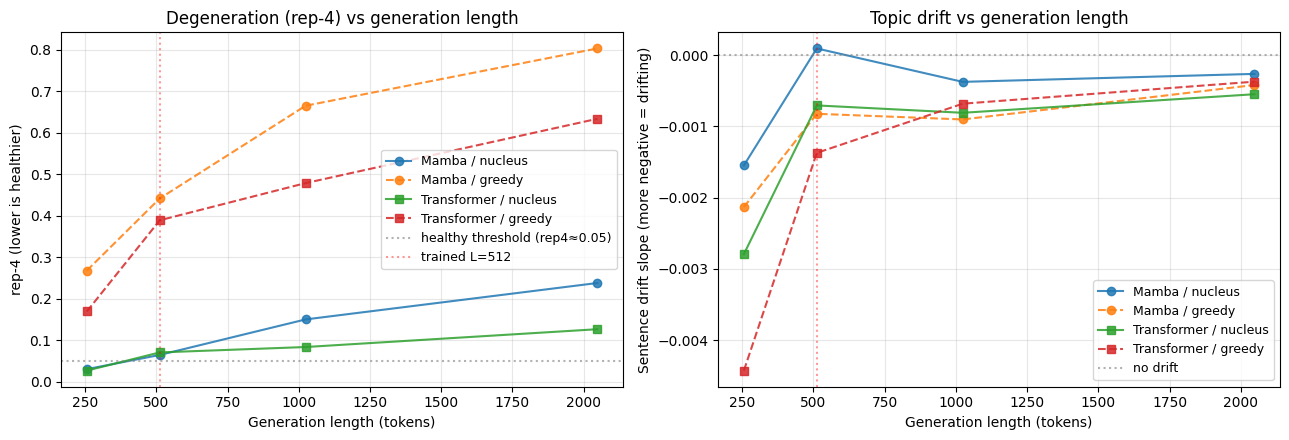

In [30]:
# Plot: rep-4 and drift slope vs generation length, per (model, mode).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
markers = {'Mamba': 'o', 'Transformer': 's'}
linestyles = {'nucleus': '-', 'greedy': '--'}

for name in degen_results:
    for mode in LF_MODES:
        rep4 = [degen_results[name][mode][L]['rep4'] for L in LF_LEN_SLICES]
        drift = [degen_results[name][mode][L]['drift_slope'] for L in LF_LEN_SLICES]
        axes[0].plot(LF_LEN_SLICES, rep4,
                     marker=markers[name], linestyle=linestyles[mode],
                     label=f'{name} / {mode}', alpha=0.85)
        axes[1].plot(LF_LEN_SLICES, drift,
                     marker=markers[name], linestyle=linestyles[mode],
                     label=f'{name} / {mode}', alpha=0.85)

axes[0].axhline(0.05, color='gray', linestyle=':', alpha=0.6,
                label='healthy threshold (rep4≈0.05)')
axes[0].axvline(SEQ_LEN, color='red', linestyle=':', alpha=0.4,
                label=f'trained L={SEQ_LEN}')
axes[0].set_xlabel('Generation length (tokens)')
axes[0].set_ylabel('rep-4 (lower is healthier)')
axes[0].set_title('Degeneration (rep-4) vs generation length')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

axes[1].axhline(0.0, color='gray', linestyle=':', alpha=0.6,
                label='no drift')
axes[1].axvline(SEQ_LEN, color='red', linestyle=':', alpha=0.4)
axes[1].set_xlabel('Generation length (tokens)')
axes[1].set_ylabel('Sentence drift slope (more negative = drifting)')
axes[1].set_title('Topic drift vs generation length')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [31]:
# ─── Metric 3: MAUVE (distributional quality vs human) ─────────────────
import mauve

# GPT-2 (the default MAUVE featurizer) has max_position_embeddings=1024.
# Passing max_text_length > 1024 causes a device-side position-embedding
# OOB assert that corrupts the CUDA context for all subsequent ops in the
# notebook — sticky and only recoverable by restarting the runtime. We
# cap the featurization length here regardless of LF_MAX_NEW; MAUVE is a
# *distributional* metric so truncating each text to 1024 still gives a
# reliable comparison between model output distributions.
MAUVE_MAX_TEXT_LEN = min(LF_MAX_NEW, 1024)

def mauve_score(model_texts, human_texts, label):
    if len(model_texts) < 8 or len(human_texts) < 8:
        print(f"  MAUVE skipped for {label}: need >=8 samples per side")
        return float('nan')
    try:
        out = mauve.compute_mauve(
            p_text=human_texts, q_text=model_texts,
            featurize_model_name='gpt2',
            max_text_length=MAUVE_MAX_TEXT_LEN,
            device_id=0 if torch.cuda.is_available() else -1,
            verbose=False,
        )
        return float(out.mauve)
    except Exception as e:
        print(f"  MAUVE failed for {label}: {e!r}")
        return float('nan')

mauve_results = {}
for name, by_mode in lf_gens.items():
    mauve_results[name] = {}
    for mode, recs in by_mode.items():
        texts = [r['text'] for r in recs]
        score = mauve_score(texts, human_refs, f"{name}/{mode}")
        mauve_results[name][mode] = score
        print(f"  MAUVE  {name:12s} {mode:8s} = {score:.3f}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Featurizing q:   0%|          | 0/40 [00:00<?, ?it/s]

  MAUVE  Transformer  nucleus  = 0.084


Featurizing p:   0%|          | 0/40 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/40 [00:00<?, ?it/s]

  MAUVE  Transformer  greedy   = 0.278


In [32]:
# ─── Metric 4: Pairwise LLM-as-judge (open-source, double-ordered) ────
judge_results = {mode: None for mode in LF_MODES}
judge_raw     = {mode: None for mode in LF_MODES}

if RUN_JUDGE:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    import json as _json

    print(f"Loading judge: {JUDGE_MODEL}")
    jtok = AutoTokenizer.from_pretrained(JUDGE_MODEL)
    if JUDGE_4BIT:
        from transformers import BitsAndBytesConfig
        bnb = BitsAndBytesConfig(load_in_4bit=True,
                                 bnb_4bit_compute_dtype=torch.bfloat16)
        jmodel = AutoModelForCausalLM.from_pretrained(
            JUDGE_MODEL, quantization_config=bnb, device_map=str(device),
        ).eval()
        print("  loaded judge in 4-bit")
    else:
        jmodel = AutoModelForCausalLM.from_pretrained(
            JUDGE_MODEL, dtype=torch.bfloat16,
        ).to(device).eval()
        print("  loaded judge in bf16")

    RUBRIC = (
        "You are grading two short children's-story continuations of the same "
        "prompt. Pick the better one on three axes:\n"
        "  - grammar:   correctness of English\n"
        "  - coherence: stable characters, no contradictions, on-topic\n"
        "  - creativity: interesting / not generic\n"
        "Reply with ONLY one valid JSON object, nothing else, in this exact "
        "schema (use \"A\", \"B\", or \"tie\" for each axis):\n"
        '{"winner":"A|B|tie","grammar":"A|B|tie","coherence":"A|B|tie","creativity":"A|B|tie"}'
    )
    JUDGE_TRUNC = 1500   # chars; verbosity-bias mitigation

    @torch.inference_mode()
    def judge_pair(prompt, text_a, text_b):
        msgs = [{"role": "system", "content": RUBRIC},
                {"role": "user",
                 "content": (f"PROMPT:\n{prompt}\n\n"
                             f"A:\n{text_a[:JUDGE_TRUNC]}\n\n"
                             f"B:\n{text_b[:JUDGE_TRUNC]}")}]
        # apply_chat_template returns BatchEncoding (dict-like) in newer
        # transformers versions and a bare tensor in older ones — handle both.
        enc = jtok.apply_chat_template(msgs, return_tensors='pt',
                                       add_generation_prompt=True)
        ids = (enc['input_ids'] if hasattr(enc, 'data') else enc).to(device)
        out = jmodel.generate(ids, max_new_tokens=80, do_sample=False,
                              pad_token_id=jtok.eos_token_id)
        txt = jtok.decode(out[0, ids.shape[-1]:], skip_special_tokens=True)
        try:
            j_open  = txt.find('{')
            j_close = txt.rfind('}')
            return _json.loads(txt[j_open:j_close + 1])
        except Exception:
            return None

    def double_ordered_winrate(gens_a, gens_b, label):
        """Run each pair in both orderings; only count A as winning if it
        wins in BOTH (model-A in slot A) AND (model-A in slot B). This
        cancels the well-known position bias of small judges.

        Returns BOTH the aggregated tally (back-compat) AND the raw
        per-pair votes — so the writeup can audit which prompts were
        decisive, which had position bias, and which the judge failed
        to parse."""
        AXES = ('winner', 'grammar', 'coherence', 'creativity')
        tally = {ax: Counter() for ax in AXES}
        raw   = []                              # per-pair (v1, v2, prompt) records
        n_pairs = min(len(gens_a), len(gens_b))
        for i in tqdm(range(n_pairs), desc=f'judge {label}'):
            a, b = gens_a[i], gens_b[i]
            v1 = judge_pair(a['prompt'], a['text'], b['text'])
            v2 = judge_pair(a['prompt'], b['text'], a['text'])
            raw.append({'prompt': a['prompt'][:80], 'v1_AB': v1, 'v2_BA': v2})
            if v1 is None or v2 is None:
                for ax in AXES: tally[ax]['parse_fail'] += 1
                continue
            for ax in AXES:
                if v1.get(ax) == 'A' and v2.get(ax) == 'B':
                    tally[ax]['model_a_wins'] += 1
                elif v1.get(ax) == 'B' and v2.get(ax) == 'A':
                    tally[ax]['model_b_wins'] += 1
                else:
                    tally[ax]['tie_or_inconsistent'] += 1
        return {ax: dict(v) for ax, v in tally.items()}, raw

    judge_raw = {mode: None for mode in LF_MODES}
    for mode in LF_MODES:
        m_recs = lf_gens['Mamba'][mode]
        x_recs = lf_gens['Transformer'][mode]
        tally, raw = double_ordered_winrate(m_recs, x_recs, mode)
        judge_results[mode] = tally
        judge_raw[mode]     = raw
        print(f"\n══ judge / {mode} (Mamba=A, Transformer=B) ══")
        for ax, t in tally.items():
            print(f"  {ax:11s} {t}")

    # Free the judge.
    del jmodel
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("RUN_JUDGE=False — skipping pairwise judge.")


Loading judge: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

judge nucleus:   0%|          | 0/40 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



══ judge / nucleus (Mamba=A, Transformer=B) ══
  winner      {'tie_or_inconsistent': 32, 'model_b_wins': 4, 'model_a_wins': 4}
  grammar     {'tie_or_inconsistent': 40}
  coherence   {'tie_or_inconsistent': 40}
  creativity  {'tie_or_inconsistent': 31, 'model_b_wins': 7, 'model_a_wins': 2}


judge greedy:   0%|          | 0/40 [00:00<?, ?it/s]


══ judge / greedy (Mamba=A, Transformer=B) ══
  winner      {'model_b_wins': 8, 'model_a_wins': 10, 'tie_or_inconsistent': 22}
  grammar     {'tie_or_inconsistent': 40}
  coherence   {'tie_or_inconsistent': 36, 'model_a_wins': 2, 'model_b_wins': 2}
  creativity  {'model_b_wins': 6, 'tie_or_inconsistent': 28, 'model_a_wins': 6}


In [33]:
# Consolidated long-form results.
lf_summary = {}
for mode in LF_MODES:
    lf_summary[mode] = {
        'mauve':            {n: mauve_results[n][mode] for n in mauve_results},
        f'rep4_at_{LF_LEN_SLICES[-1]}':  {n: degen_results[n][mode][LF_LEN_SLICES[-1]]['rep4']
                                          for n in degen_results},
        f'drift_at_{LF_LEN_SLICES[-1]}': {n: degen_results[n][mode][LF_LEN_SLICES[-1]]['drift_slope']
                                          for n in degen_results},
    }
    if judge_results.get(mode):
        lf_summary[mode]['judge'] = judge_results[mode]
df_lf = pd.DataFrame({mode: lf_summary[mode] for mode in LF_MODES}).T
df_lf


,mauve,rep4_at_2048,drift_at_2048,judge
nucleus,"{'Mamba': 0.7944417603395052, 'Transformer': 0...","{'Mamba': 0.23771393643031785, 'Transformer': ...","{'Mamba': -0.0002647058361524623, 'Transformer...","{'winner': {'tie_or_inconsistent': 32, 'model_..."
greedy,"{'Mamba': 0.22209667048861204, 'Transformer': ...","{'Mamba': 0.8034718826405868, 'Transformer': 0...","{'Mamba': -0.0004205145800321794, 'Transformer...","{'winner': {'model_b_wins': 8, 'model_a_wins':..."


## Summary

Bring the headline numbers into one table. The interpretation:

* `bpb` and `top1/top5` — **lower bpb is better**, **higher top-k is better**. Quality.
* `decode_latency_ms` and `prefill_L*_tps` — **decode is Mamba's selling point**. Lower latency, higher tps = faster serving.
* `state_kb_at_L=512` — **lower is better at fixed L**, but the Mamba advantage compounds at long L (see Experiment 2 plot).
* `induction_2afc_at_n=64` and `=256` — **higher is better; 50% = random**. Tests architectural capability for in-context retrieval. Above 55% is meaningfully above chance at n=500 trials. The relative gap between Mamba and the Transformer at the longest distance is the key signal.
* `self_bleu` — **lower is more diverse**. `distinct_2` — **higher is more diverse**. `repetition_rate` — **lower is healthier**.
* `mauve_nucleus`, `rep4_at_2048`, `drift_at_2048` — long-form generation quality. **MAUVE higher better**, **rep-4 lower better**, **drift-slope nearer to 0 better**. The story for the writeup is the *trajectory* across slice lengths {256, 512, 1024, 2048} — does Mamba degrade past the trained context (L=512) more or less than the transformer?


In [34]:
def safe_get(d, *keys, default=float('nan')):
    for k in keys:
        if d is None or k not in d:
            return default
        d = d[k]
    return d

summary = {}
for iface in (mamba_iface, xfmr_iface):
    name = iface.name
    # Needle: average 2AFC across depths at each L.
    needle_avg = {}
    for L_total in needle_results.get(name, {}):
        vals = [needle_results[name][L_total][k]['top1_2afc']
                for k in needle_results[name][L_total]]
        if vals:
            needle_avg[L_total] = float(np.mean(vals))
    summary[name] = {
        'n_params':                 iface.n_params,
        'test_loss':                results_test[name]['loss'],
        'test_perplexity':          results_test[name]['perplexity'],
        'test_bpb':                 results_test[name]['bpb'],
        'test_top1':                results_test[name]['top1'],
        'test_top5':                results_test[name]['top5'],
        # Out-of-distribution (Experiment 1b) — same model, WikiText.
        'ood_loss':                 results_ood[name]['loss'],
        'ood_perplexity':           results_ood[name]['perplexity'],
        # Inference (Experiment 2 / 2b / 2c)
        'decode_tps':               results_inf[name]['decode_tps'],
        'decode_latency_ms':        results_inf[name]['decode_latency_ms'],
        f'prefill_L512_tps':        results_inf[name].get('prefill_L512_tps', float('nan')),
        f'state_kb_at_L=512':       iface.state_size_bytes(1, 512) / 1024,
        f'state_kb_at_L=2048':      iface.state_size_bytes(1, 2048) / 1024,
        # FLOPs (Experiment 2c) — quality-per-FLOP metric for the writeup.
        'flops_per_token_L=512':    flops_results['L=512'][f'{name}_flops_per_token'],
        # Induction (Experiment 5) and needle (Experiment 5b).
        f'induction_2afc_at_n=64':  safe_get(ind_results.get(name, {}).get(64), 'top1_2afc'),
        f'induction_2afc_at_n=256': safe_get(ind_results.get(name, {}).get(256), 'top1_2afc'),
        f'needle_2afc_avg_at_L=512':   needle_avg.get(512, float('nan')),
        f'needle_2afc_avg_at_L=1024':  needle_avg.get(1024, float('nan')),
        f'needle_2afc_avg_at_L=2048':  needle_avg.get(2048, float('nan')),
        # Diversity (Experiment 6)
        'diversity_self_bleu':      div_results[name]['self_bleu'],
        'diversity_distinct_2':     div_results[name]['distinct_2'],
        'diversity_repetition':     div_results[name]['repetition_rate'],
        # Long-form (Experiment 7) — nucleus mode at the deepest slice.
        'longform_mauve_nucleus':            safe_get(mauve_results, name, 'nucleus'),
        f'longform_rep4_at_{LF_LEN_SLICES[-1]}':  safe_get(degen_results, name, 'nucleus',
                                                           LF_LEN_SLICES[-1], 'rep4'),
        f'longform_drift_at_{LF_LEN_SLICES[-1]}': safe_get(degen_results, name, 'nucleus',
                                                           LF_LEN_SLICES[-1], 'drift_slope'),
    }

df_summary = pd.DataFrame(summary).T
df_summary.index.name = 'model'
df_summary


,n_params,test_loss,test_perplexity,test_bpb,test_top1,test_top5,ood_loss,ood_perplexity,decode_tps,decode_latency_ms,...,induction_2afc_at_n=256,needle_2afc_avg_at_L=512,needle_2afc_avg_at_L=1024,needle_2afc_avg_at_L=2048,diversity_self_bleu,diversity_distinct_2,diversity_repetition,longform_mauve_nucleus,longform_rep4_at_2048,longform_drift_at_2048
model,,,,,,,,,,,,,,,,,,,,,
Mamba,5138432.0,1.917815,6.806070,0.643588,0.522532,0.802192,6.603444,737.631484,432.138291,2.314074,...,0.53,0.177778,0.077778,0.200000,0.186793,0.772204,0.061378,0.794442,0.237714,-0.000265
Transformer,5374208.0,1.885000,6.586355,0.632576,0.529018,0.808615,6.608856,741.634212,137.539990,7.270613,...,0.55,0.200000,0.177778,0.122222,0.197821,0.750285,0.076062,0.083512,0.126235,-0.000550


In [35]:
# ─── Reproducibility metadata ──────────────────────────────────────────
# Capture the EXACT environment so a future re-runner can match this run.
import platform
try:
    import transformers as _hf
    _hf_ver = _hf.__version__
except ImportError:
    _hf_ver = None
try:
    import triton as _triton
    _triton_ver = _triton.__version__
except ImportError:
    _triton_ver = None

env_meta = {
    'torch_version':       torch.__version__,
    'transformers_version': _hf_ver,
    'triton_version':      _triton_ver,
    'cuda_available':      torch.cuda.is_available(),
    'cuda_device_name':    torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'cuda_capability':     list(torch.cuda.get_device_capability(0)) if torch.cuda.is_available() else None,
    'python_version':      platform.python_version(),
    'platform':            platform.platform(),
}

run_flags = {
    'USE_TORCH_COMPILE':   USE_TORCH_COMPILE,
    'USE_CUDA_GRAPHS':     USE_CUDA_GRAPHS,
    'JUDGE_4BIT':          JUDGE_4BIT,
    'RUN_JUDGE':           RUN_JUDGE,
    'EVAL_BATCH_SIZE':     EVAL_BATCH_SIZE,
    'DTYPE':               str(DTYPE),
    'INFERENCE_DTYPE_DEPLOY': str(INFERENCE_DTYPE_DEPLOY),
}

# Save the consolidated results to JSON for the writeup.
out = {
    'config': {
        'mamba_checkpoint':       MAMBA_CHECKPOINT_PATH,
        'transformer':            HF_TRANSFORMER_MODEL,
        'tokenizer':              HF_TOKENIZER,
        'tokenizer_vocab_size':   len(tokenizer),
        'dataset':                DATASET_NAME,
        'split':                  DATASET_SPLIT,
        'lowercase':              LOWERCASE,
        'seq_len':                SEQ_LEN,
        'n_test_stories':         len(ds),
        'n_test_chunks':          int(test_data.shape[0]),
        'n_test_tokens':          int(test_data.shape[0]) * (int(test_data.shape[1]) - 1),
        'bytes_per_token':        bytes_per_token,
        'mamba_checkpoint_meta':  {k: mamba_payload.get(k) for k in
                                   ('global_step', 'epoch', 'val_loss',
                                    'best_val', 'best_val_ppl')},
    },
    'environment':             env_meta,
    'run_flags':               run_flags,
    'experiment_1_test':       results_test,
    'experiment_1b_ood':       {
        'dataset':         OOD_DATASET,
        'config':          OOD_CONFIG,
        'split':           OOD_SPLIT,
        'n_chunks':        int(ood_data.shape[0]),
        'bytes_per_token': ood_bpt,
        'results':         results_ood,
    },
    'experiment_2_inference':  results_inf,             # fp32 (back-compat)
    'experiment_2_inference_fp32':   results_inf_fp32,
    'experiment_2_inference_deploy': results_inf_deploy,
    'experiment_2_state':      df_state.reset_index().to_dict(orient='records'),
    'experiment_2b_inference_batched': results_inf_batched,
    'experiment_2c_flops':     flops_results,
    'experiment_3_loss_vs_len': len_results,
    'experiment_4_per_pos':    {k: v.tolist() for k, v in per_pos.items()},
    'experiment_5_induction':  ind_results,
    'experiment_5b_needle':    {
        'config': {
            'lens':                    NEEDLE_LENS,
            'depths':                  NEEDLE_DEPTHS,
            'trials_per_pair':         NEEDLE_TRIALS,
            'distractors_per_trial':   NEEDLE_DISTRACTORS_PER_TRIAL,
            'n_single_token_keys':     len(needle_key_ids),
        },
        'results': needle_results,
    },
    'experiment_6_diversity':  div_results,
    'experiment_7_longform':   {
        'config': {
            'n_prompts':       LF_N_PROMPTS,
            'gens_per_prompt': LF_GENS_PER_P,
            'max_new_tokens':  LF_MAX_NEW,
            'len_slices':      LF_LEN_SLICES,
            'suppress_eos':    LF_SUPPRESS_EOS,
            'modes':           {k: v for k, v in LF_MODES.items()},
            'judge_model':     JUDGE_MODEL if RUN_JUDGE else None,
            'judge_dtype':     '4bit' if JUDGE_4BIT else 'bf16',
        },
        'mauve':         mauve_results,
        'degeneration':  degen_results,         # now includes per-prompt arrays
        'judge':         judge_results,
        'judge_raw_votes': judge_raw,           # per-pair (v1, v2) for audit
        'sample_texts':  sample_texts,          # 4 generations per (model, mode)
        'summary':       lf_summary,
    },
    'summary':                 summary,
}
out_path = 'simplestories_eval_results.json'
with open(out_path, 'w') as f:
    json.dump(out, f, indent=2, default=str)
print(f"Wrote {out_path}")
print(f"  config keys: {list(out['config'].keys())}")
print(f"  environment captured: {list(env_meta.keys())}")


Wrote simplestories_eval_results.json
  config keys: ['mamba_checkpoint', 'transformer', 'tokenizer', 'tokenizer_vocab_size', 'dataset', 'split', 'lowercase', 'seq_len', 'n_test_stories', 'n_test_chunks', 'n_test_tokens', 'bytes_per_token', 'mamba_checkpoint_meta']
  environment captured: ['torch_version', 'transformers_version', 'triton_version', 'cuda_available', 'cuda_device_name', 'cuda_capability', 'python_version', 'platform']


---

**Done.** The results are in `simplestories_eval_results.json` plus the dataframes above.

For the writeup, the natural three-act structure is:
1. **Quality**: Experiments 1, 6, 7 — does Mamba match the transformer at fixed param budget on test BPB, generation diversity, and long-form metrics (MAUVE / rep-4 / drift / pairwise judge)?
2. **Efficiency**: Experiment 2 — does Mamba deliver the predicted serving advantages (decode tps + constant-size state)?
3. **Why**: Experiments 3, 4, 5, and the length-slice trajectory in 7 — long-context extrapolation, context use, in-context retrieval — explain the architectural differences. Experiment 7's slice-at-{256, 512, 1024, 2048} curves are the qualitative analog of Experiment 3's loss-vs-length: does the long-form quality degrade past the trained context, and if so, which model degrades faster?
